In [120]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, skew
import missingno as msno

In [121]:
pd.set_option('display.max_columns',None)

<h1 style="text-align: center; color: blue;">
    XEM TỔNG QUAN DỮ LIỆU
</h1>

In [122]:
train = pd.read_csv('AmesHousing.csv')
train.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [123]:
train.columns = train.columns.str.replace(' ','')
train = train.drop('PID',axis=1).rename(columns={'Order':'Id'})
train.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000


In [124]:
train.shape

(2930, 81)

In [125]:
test = pd.read_csv('test.csv')
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [126]:
test.shape

(1459, 80)

In [127]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2930 non-null   int64  
 1   MSSubClass     2930 non-null   int64  
 2   MSZoning       2930 non-null   str    
 3   LotFrontage    2440 non-null   float64
 4   LotArea        2930 non-null   int64  
 5   Street         2930 non-null   str    
 6   Alley          198 non-null    str    
 7   LotShape       2930 non-null   str    
 8   LandContour    2930 non-null   str    
 9   Utilities      2930 non-null   str    
 10  LotConfig      2930 non-null   str    
 11  LandSlope      2930 non-null   str    
 12  Neighborhood   2930 non-null   str    
 13  Condition1     2930 non-null   str    
 14  Condition2     2930 non-null   str    
 15  BldgType       2930 non-null   str    
 16  HouseStyle     2930 non-null   str    
 17  OverallQual    2930 non-null   int64  
 18  OverallCond    2930

In [128]:
train['SalePrice'].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

<Axes: xlabel='SalePrice', ylabel='Count'>

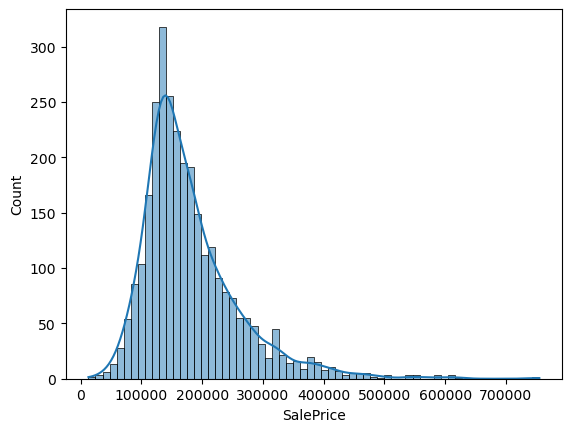

In [129]:
sns.histplot(train['SalePrice'],kde =True)

In [130]:
# Độ lệch và độ nhọn
print('Skewness of SalePrice:',train['SalePrice'].skew())
print('Kurtosis of SalePrice:',train['SalePrice'].kurt())

Skewness of SalePrice: 1.7435000757376466
Kurtosis of SalePrice: 5.118899951130896


In [131]:
train['SalePrice'] = np.log1p(train['SalePrice'])

<Axes: xlabel='SalePrice', ylabel='Count'>

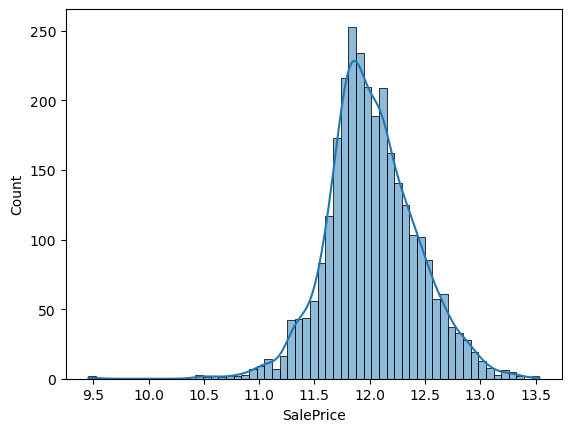

In [132]:
sns.histplot(train['SalePrice'],kde = True)

In [133]:
print('Skewness of SalePrice:',train['SalePrice'].skew())
print('Kurtosis of SalePrice:',train['SalePrice'].kurt())

Skewness of SalePrice: -0.014772659537224368
Kurtosis of SalePrice: 1.5138180928006526


<h1 style="text-align: center; color: blue;">
    MỐI QUAN HỆ GIỮA CÁC BIẾN
</h1>

In [134]:
cols = train.select_dtypes(include = ['int64','float64']).corr()['SalePrice']
strongcol = cols[abs(cols) > 0.5]
strongcol

OverallQual      0.825645
YearBuilt        0.615485
YearRemod/Add    0.586153
TotalBsmtSF      0.625099
1stFlrSF         0.602629
GrLivArea        0.695863
FullBath         0.577335
GarageYrBlt      0.580502
GarageCars       0.675318
GarageArea       0.651132
SalePrice        1.000000
Name: SalePrice, dtype: float64

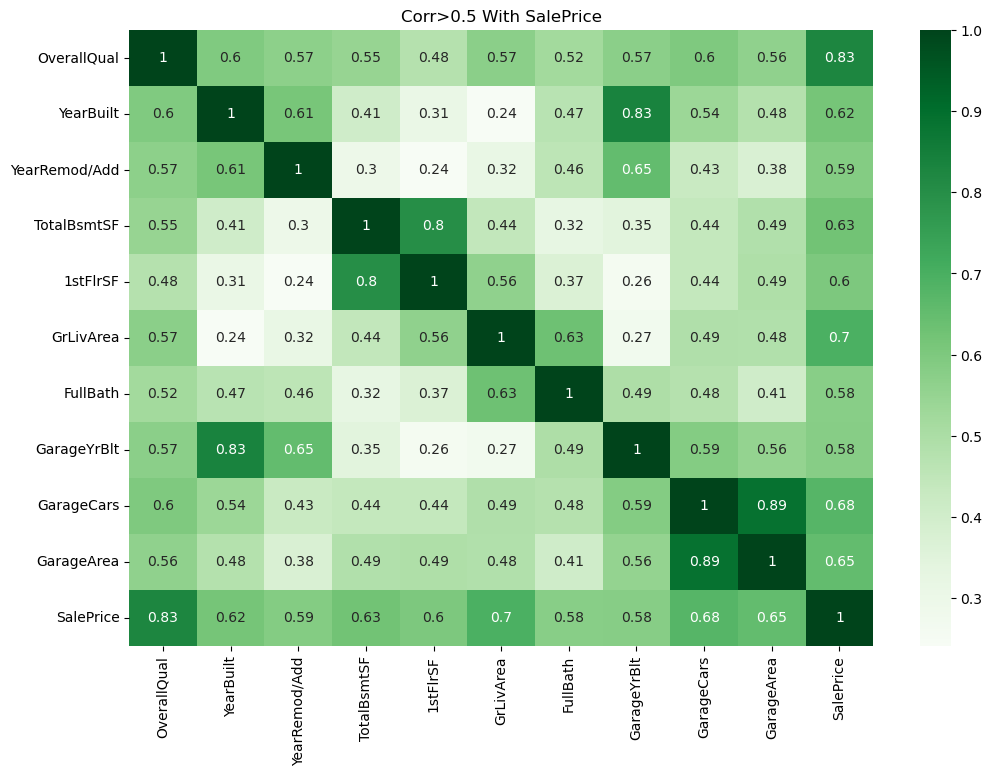

In [135]:
plt.figure(figsize=(12, 8))
sns.heatmap(train[strongcol.index].corr(),annot=True,cmap="Greens")
plt.title("Corr>0.5 With SalePrice")
plt.show()

In [136]:
#  ['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'FullBath', 'GarageYrBlt', 'GarageCars', 'GarageArea']
# GarageCars và GarageArea và GarageYrBlt chọn ra 1
# TotalBsmtSF và 1stFlrSF
# YearBuilt và YearRemodAdd

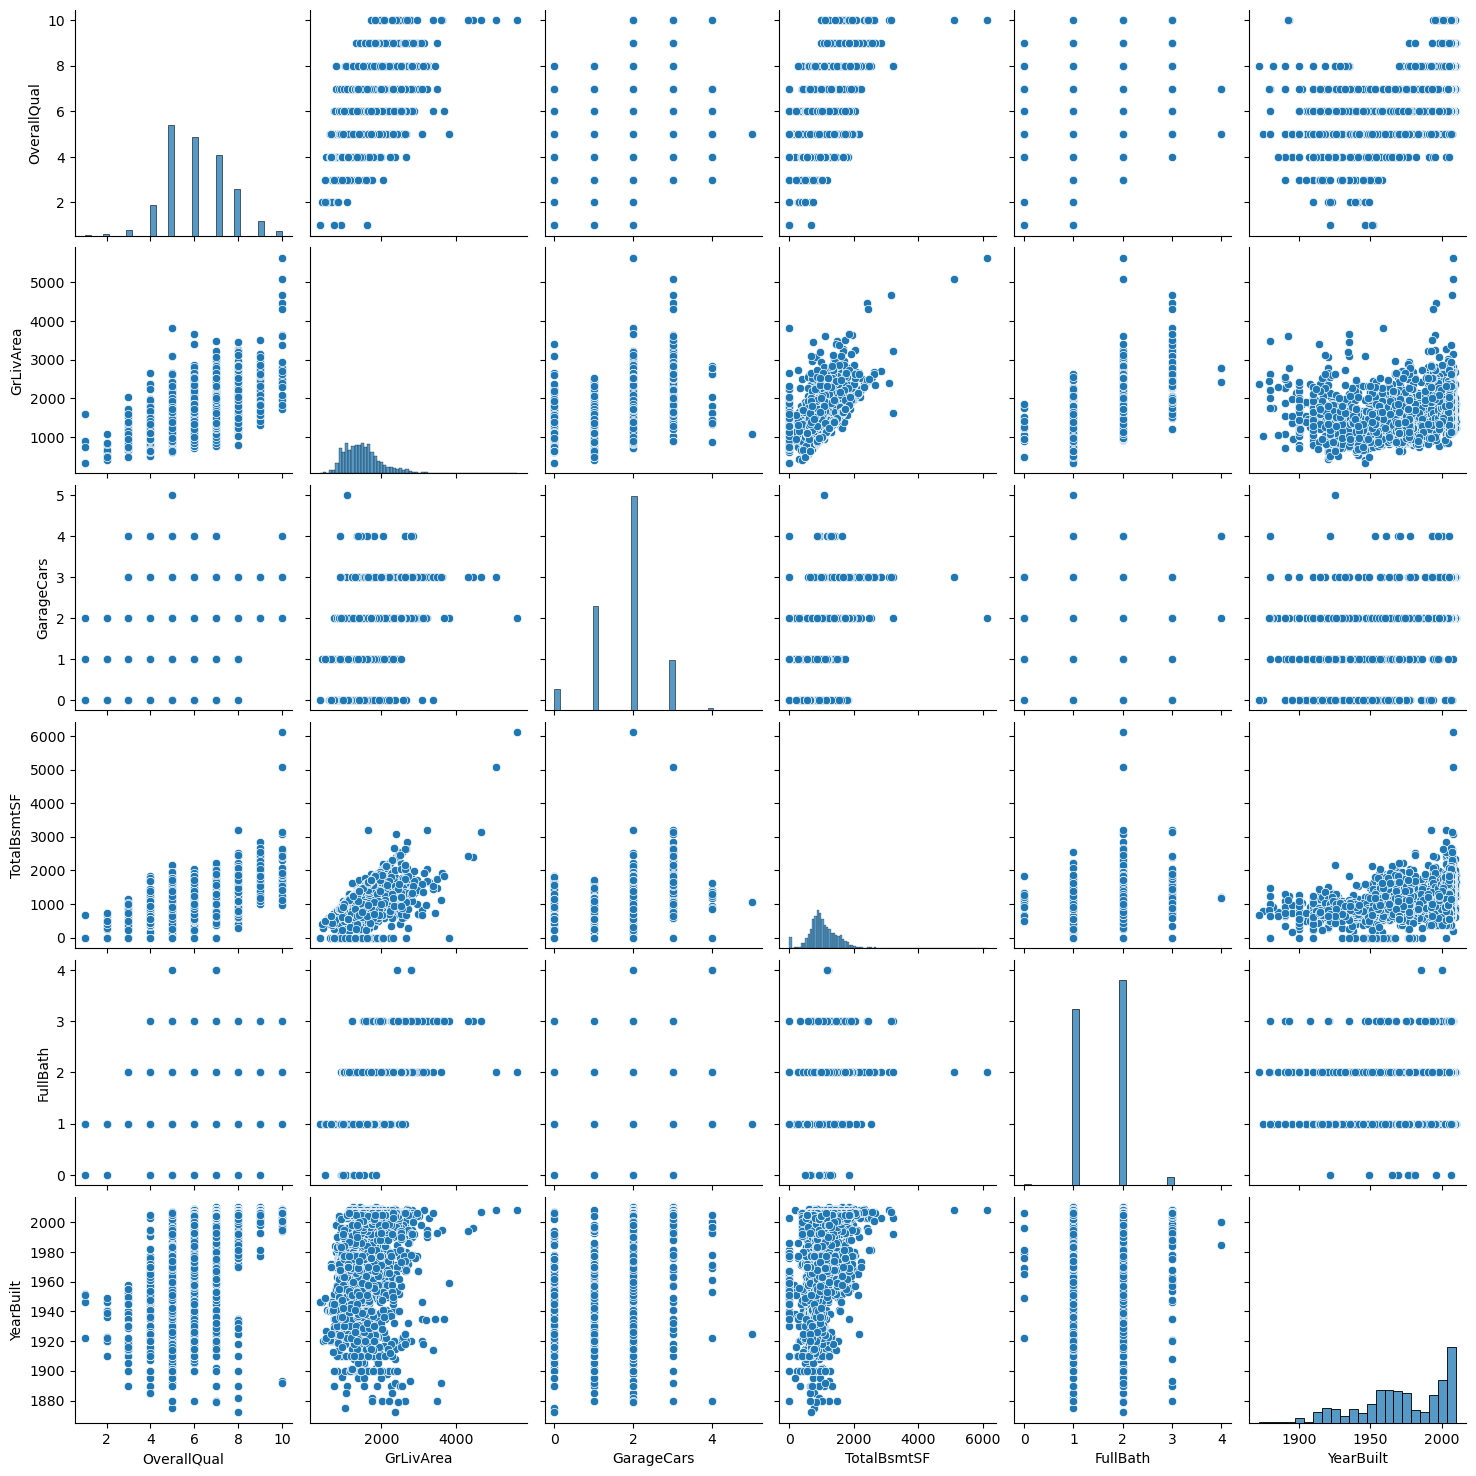

In [137]:
cols = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
sns.pairplot(train[cols])

In [138]:
x = ['OverallQual', 'YearBuilt', 'YearRemod/Add', 'TotalBsmtSF', '1stFlrSF',
       'GrLivArea', 'FullBath', 'GarageYrBlt', 'GarageCars', 'GarageArea',
       'SalePrice']
for cols in x:
    cols1 = train.select_dtypes(include=['int64', 'float64']).corr()[cols]
    cols1 = cols1[abs(cols1) > 0.5]
    print(f'{cols}',cols1,sep = '\n')

OverallQual
OverallQual      1.000000
YearBuilt        0.597027
YearRemod/Add    0.569609
TotalBsmtSF      0.547294
GrLivArea        0.570556
FullBath         0.522263
GarageYrBlt      0.570569
GarageCars       0.599545
GarageArea       0.563503
SalePrice        0.825645
Name: OverallQual, dtype: float64
YearBuilt
OverallQual      0.597027
YearBuilt        1.000000
YearRemod/Add    0.612095
GarageYrBlt      0.834849
GarageCars       0.537443
SalePrice        0.615485
Name: YearBuilt, dtype: float64
YearRemod/Add
OverallQual      0.569609
YearBuilt        0.612095
YearRemod/Add    1.000000
GarageYrBlt      0.652310
SalePrice        0.586153
Name: YearRemod/Add, dtype: float64
TotalBsmtSF
OverallQual    0.547294
BsmtFinSF1     0.536547
TotalBsmtSF    1.000000
1stFlrSF       0.800720
SalePrice      0.625099
Name: TotalBsmtSF, dtype: float64
1stFlrSF
TotalBsmtSF    0.800720
1stFlrSF       1.000000
GrLivArea      0.562166
SalePrice      0.602629
Name: 1stFlrSF, dtype: float64
GrLivArea
Over

In [139]:
# OverallQual có tương quan với:
#YearBuilt(0.5970),YearRemod/Add(0.5696),TotalBsmtSF(0.5473),GrLivArea(0.5706),FullBath(0.5223),GarageYrBlt(0.5706),GarageCars(0.5995),GarageArea(0.5635),SalePrice(0.8256)

# YearBuilt có tương quan với:
# OverallQual(0.5970),YearRemod/Add(0.6121),GarageYrBlt(0.8348),GarageCars(0.5374),SalePrice(0.6155)

# YearRemod/Add có tương quan với:
# OverallQual(0.5696),YearBuilt(0.6121),GarageYrBlt(0.6523),SalePrice(0.5862)

# TotalBsmtSF có tương quan với:
# OverallQual(0.5473),BsmtFinSF1(0.5365),1stFlrSF(0.8007),SalePrice(0.6251)

# 1stFlrSF có tương quan với:
# TotalBsmtSF(0.8007),GrLivArea(0.5622),SalePrice(0.6026)

# GrLivArea có tương quan với:
# OverallQual(0.5706),1stFlrSF(0.5622),2ndFlrSF(0.6553),FullBath(0.6303),BedroomAbvGr(0.5168),TotRmsAbvGrd(0.8078),SalePrice(0.6959)

# FullBath có tương quan với:
# OverallQual(0.5223),GrLivArea(0.6303),TotRmsAbvGrd(0.5286),SalePrice(0.5773)

# GarageYrBlt có tương quan với:
# OverallQual(0.5706),YearBuilt(0.8348),YearRemod/Add(0.6523),GarageCars(0.5867),GarageArea(0.5550),SalePrice(0.5805)

# GarageCars có tương quan với:
# OverallQual(0.5995),YearBuilt(0.5374),GarageYrBlt(0.5867),GarageArea(0.8897),SalePrice(0.6753)

# GarageArea có tương quan với:
# OverallQual(0.5635),GarageYrBlt(0.5550),GarageCars(0.8897),SalePrice(0.6511)

In [140]:
# Một số cặp biến tương quan cao với SalePrice có tương quan cao với nhau:
# GarageCars và GarageArea       : 0.8897
# YearBuilt và GarageYrBlt       : 0.8348
# GrLivArea và TotRmsAbvGrd      : 0.8078
# TotalBsmtSF và 1stFlrSF        : 0.8007

# Các cặp biến trên cùng phản ánh những đặc điểm gần giống nhau
# Ví dụ như quy mô garage, thời gian xây dựng và diện tích căn nhà.
# Vì vậy, dữ liệu có dấu hiệu đa cộng tuyến.

# Không loại bỏ ngay các biến tương quan cao vì mỗi biến vẫn có thể chứa thông tin riêng. 
# VD: GarageCars phản ánh sức chứa theo số lượng ô tô, trong khi GarageArea phản ánh diện tích thực tế của nhà để xe.
# Việc loại bỏ một trong hai biến có thể làm mất một phần thông tin hữu ích đối với quá trình dự đoán.
# Ridge Regression được sử dụng để làm giảm ảnh hưởng của đa cộng tuyến bằng điều chuẩn L2
# => giúp thu nhỏ và ổn định các hệ số hồi quy mà không loại bỏ hoàn toàn các biến.

<h1 style="text-align: center; color: blue;">
    XỬ LÝ MISSING VALUE
</h1>

In [141]:
data = pd.concat([train, test], axis=0).drop(['Id','SalePrice'], axis=1)
data.shape

(4389, 80)

In [142]:
nan_count = data.isnull().sum().sort_values(ascending = False)
nan_percent = nan_count/len(data)
miss = pd.concat([nan_count,nan_percent],axis = 1,keys = ['nan_count','nan_percent'])
miss = miss[miss['nan_count']>0]
miss

,nan_count,nan_percent
PoolQC,4373,0.996355
MiscFeature,4232,0.964229
Alley,4084,0.930508
Fence,3527,0.803600
YearRemodAdd,2930,0.667578
MasVnrType,2669,0.608111
FireplaceQu,2152,0.490317
YearRemod/Add,1459,0.332422
LotFrontage,717,0.163363
GarageCond,237,0.053999


In [143]:
nan_count.sum()

np.int64(28016)

In [144]:
train_null = train.drop('Id',axis=1).isnull().sum()
test_null = test.drop('Id',axis=1).isnull().sum()
df_null = pd.concat([train_null,test_null], axis=1, keys=['train_null','test_null'])
df_null.sort_values(by='train_null',ascending=False).T

,PoolQC,MiscFeature,Alley,Fence,MasVnrType,FireplaceQu,LotFrontage,GarageYrBlt,GarageQual,GarageCond,GarageFinish,GarageType,BsmtExposure,BsmtFinType2,BsmtQual,BsmtFinType1,BsmtCond,MasVnrArea,BsmtFullBath,BsmtHalfBath,BsmtFinSF2,GarageArea,TotalBsmtSF,BsmtFinSF1,Electrical,BsmtUnfSF,GarageCars,LotShape,MSSubClass,MSZoning,Street,LotArea,HouseStyle,BldgType,Condition2,Condition1,Neighborhood,LandSlope,LotConfig,Utilities,LandContour,Foundation,ExterQual,YearRemod/Add,RoofStyle,ExterCond,YearBuilt,OverallQual,LowQualFinSF,GrLivArea,1stFlrSF,2ndFlrSF,CentralAir,HeatingQC,Heating,OverallCond,Exterior2nd,Exterior1st,RoofMatl,Fireplaces,KitchenAbvGr,Functional,TotRmsAbvGrd,KitchenQual,FullBath,HalfBath,BedroomAbvGr,PavedDrive,EnclosedPorch,3SsnPorch,OpenPorchSF,WoodDeckSF,PoolArea,ScreenPorch,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,YearRemodAdd
train_null,2917.0,2824.0,2732.0,2358.0,1775.0,1422.0,490.0,159.0,159.0,159.0,159.0,157.0,83.0,81.0,80.0,80.0,80.0,23.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
test_null,1456.0,1408.0,1352.0,1169.0,894.0,730.0,227.0,78.0,78.0,78.0,78.0,76.0,44.0,42.0,44.0,42.0,45.0,15.0,2.0,2.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,0.0


In [145]:
# MasVnrType và MasVnrArea có tương quan với nhau MasVnrType có thể bị ảnh hưởng bới MasVnrArea nên k fill None ngay đc

In [146]:
data['MasVnrArea'].isna().sum()

np.int64(38)

In [147]:
data['MasVnrType'].isna().sum()

np.int64(2669)

In [148]:
missing_both = data[data['MasVnrType'].isna() & data['MasVnrArea'].isna()]
missing_both.shape[0]

38

In [150]:
missing_both.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,YearRemodAdd
55,60,RL,NaN,7851,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,2002,2002.0,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,GLQ,625.0,Unf,0.0,235.0,860.0,GasA,Ex,Y,SBrkr,860,1100,0,1960,1.0,0.0,2,1,4,1,Gd,8,Typ,2,TA,BuiltIn,2002.0,Fin,2.0,440.0,TA,TA,Y,288,48,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,NaN
484,60,RL,NaN,12891,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Gilbert,Norm,Norm,1Fam,2Story,8,5,2002,2002.0,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Ex,TA,No,GLQ,651.0,Unf,0.0,219.0,870.0,GasA,Ex,Y,SBrkr,878,1126,0,2004,1.0,0.0,2,1,4,1,Gd,8,Typ,1,Gd,BuiltIn,2002.0,Fin,3.0,644.0,TA,TA,Y,0,48,0,0,0,0,NaN,NaN,NaN,0,7,2009,WD,Normal,NaN
517,20,FV,90.0,7993,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,7,5,2008,2009.0,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Ex,TA,No,Unf,0.0,Unf,0.0,1436.0,1436.0,GasA,Ex,Y,SBrkr,1436,0,0,1436,0.0,0.0,2,0,3,1,Gd,6,Typ,0,NaN,Attchd,2008.0,Fin,2.0,529.0,TA,TA,Y,0,121,0,0,0,0,NaN,NaN,NaN,0,10,2009,New,Partial,NaN
538,20,RL,67.0,10083,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,SawyerW,Norm,Norm,1Fam,1Story,7,5,2003,2003.0,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,GLQ,833.0,Unf,0.0,343.0,1176.0,GasA,Ex,Y,SBrkr,1200,0,0,1200,1.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,2003.0,RFn,2.0,555.0,TA,TA,Y,0,41,0,0,0,0,NaN,NaN,NaN,0,8,2009,WD,Normal,NaN
867,60,RL,70.0,8749,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2002,2002.0,Gable,CompShg,VinylSd,VinylSd,NaN,NaN,Gd,TA,PConc,Gd,TA,No,Unf,0.0,Unf,0.0,840.0,840.0,GasA,Ex,Y,SBrkr,840,885,0,1725,0.0,0.0,2,1,3,1,Gd,6,Typ,0,NaN,Attchd,2002.0,RFn,2.0,550.0,TA,TA,Y,0,48,0,0,0,0,NaN,NaN,NaN,0,11,2009,WD,Normal,NaN


<Axes: >

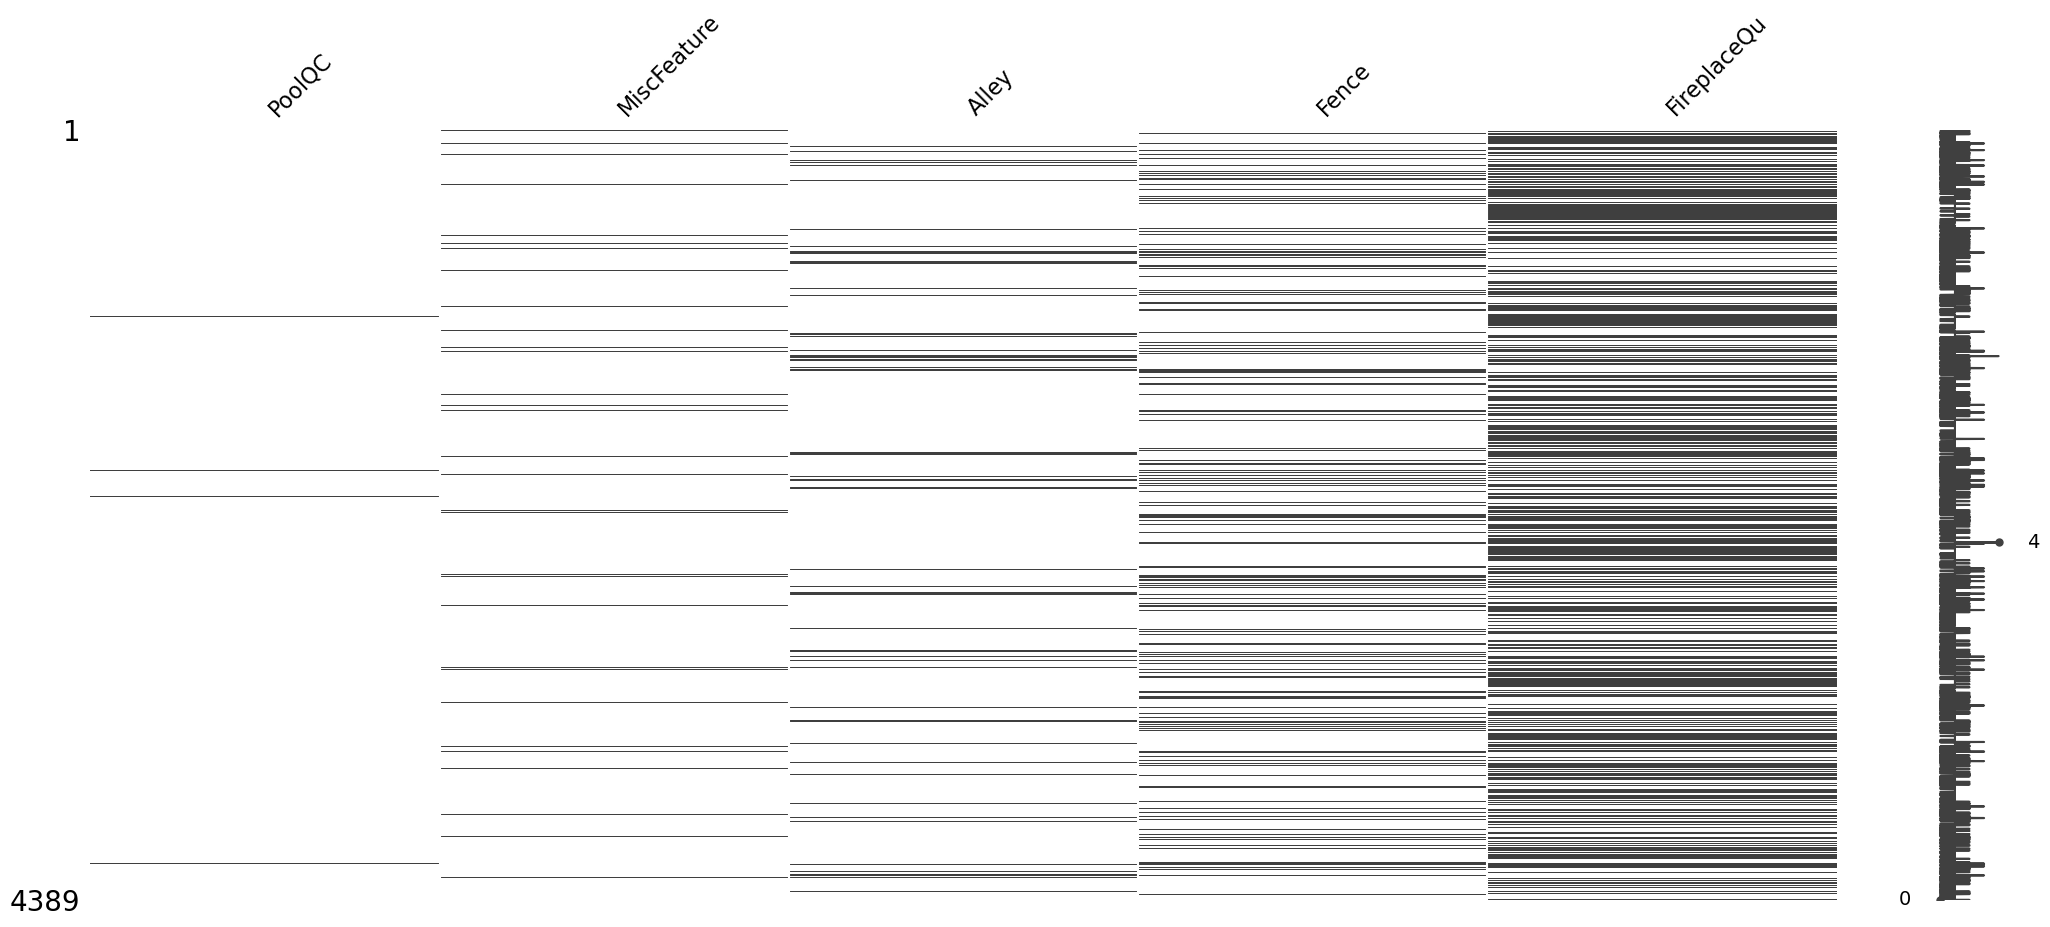

In [151]:
msno.matrix(data[['PoolQC','MiscFeature','Alley','Fence','FireplaceQu']])

<Axes: >

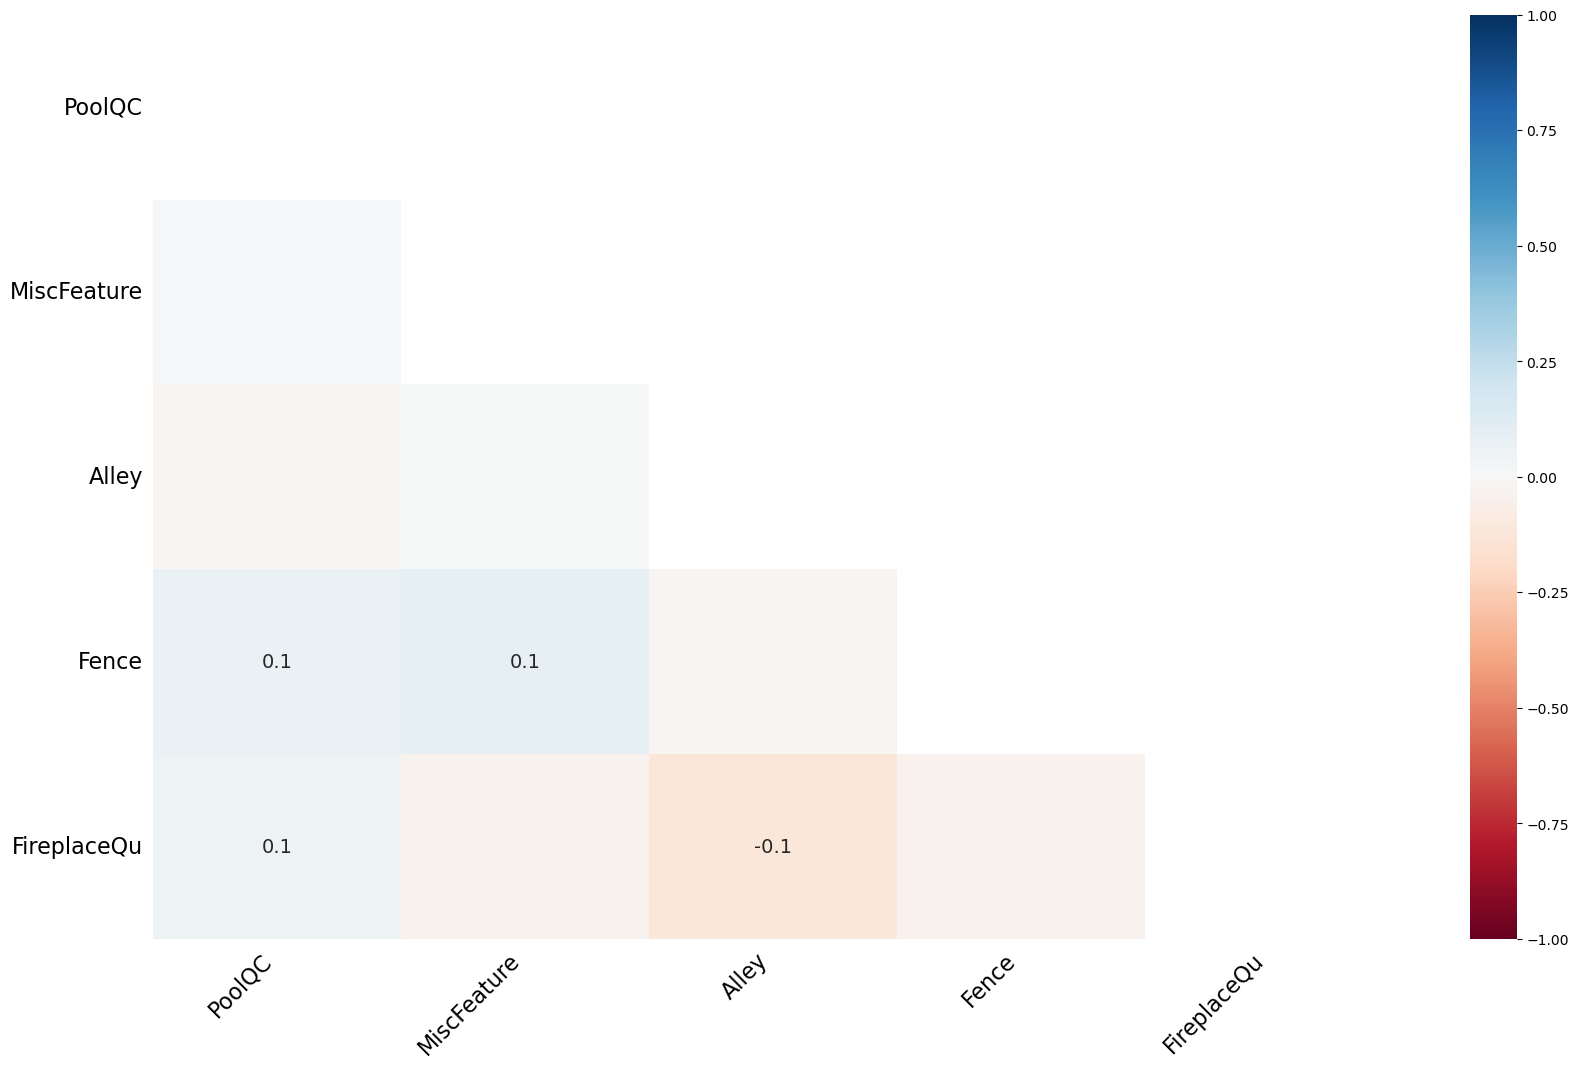

In [152]:
msno.heatmap(data[['PoolQC','MiscFeature','Alley','Fence','FireplaceQu']])

In [33]:
na = ['Alley','Fence','FireplaceQu','PoolQC','MiscFeature']
train[na] = train[na].fillna('None')
test[na] = test[na].fillna('None')

In [34]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemod/Add,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,20,RL,141.0,31770,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,None,None,None,0,5,2010,WD,Normal,12.278398
1,2,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,None,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,None,MnPrv,None,0,6,2010,WD,Normal,11.561725
2,3,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,None,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,None,None,Gar2,12500,6,2010,WD,Normal,12.055256
3,4,20,RL,93.0,11160,Pave,None,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,None,None,None,0,4,2010,WD,Normal,12.404928
4,5,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,None,MnPrv,None,0,3,2010,WD,Normal,12.154258


In [35]:
#Xử lý null các biến tương quan thấp so với SalePrice

In [36]:
fill_nan = miss[miss['nan_percent'] <= 0.1].index.tolist()
fill_nan

['GarageCond',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageType',
 'BsmtExposure',
 'BsmtCond',
 'BsmtQual',
 'BsmtFinType2',
 'BsmtFinType1',
 'MasVnrArea',
 'BsmtFullBath',
 'MSZoning',
 'BsmtHalfBath',
 'GarageArea',
 'BsmtFinSF2',
 'BsmtFinSF1',
 'BsmtUnfSF',
 'GarageCars',
 'Utilities',
 'Functional',
 'TotalBsmtSF',
 'KitchenQual',
 'Electrical',
 'SaleType',
 'Exterior1st',
 'Exterior2nd']

In [37]:
data[fill_nan].dtypes

GarageCond          str
GarageYrBlt     float64
GarageFinish        str
GarageQual          str
GarageType          str
BsmtExposure        str
BsmtCond            str
BsmtQual            str
BsmtFinType2        str
BsmtFinType1        str
MasVnrArea      float64
BsmtFullBath    float64
MSZoning            str
BsmtHalfBath    float64
GarageArea      float64
BsmtFinSF2      float64
BsmtFinSF1      float64
BsmtUnfSF       float64
GarageCars      float64
Utilities           str
Functional          str
TotalBsmtSF     float64
KitchenQual         str
Electrical          str
SaleType            str
Exterior1st         str
Exterior2nd         str
dtype: object

In [38]:
num_fill = train[fill_nan].select_dtypes(['float64']).columns
cate_fill = train[fill_nan].select_dtypes(['str']).columns

<Axes: >

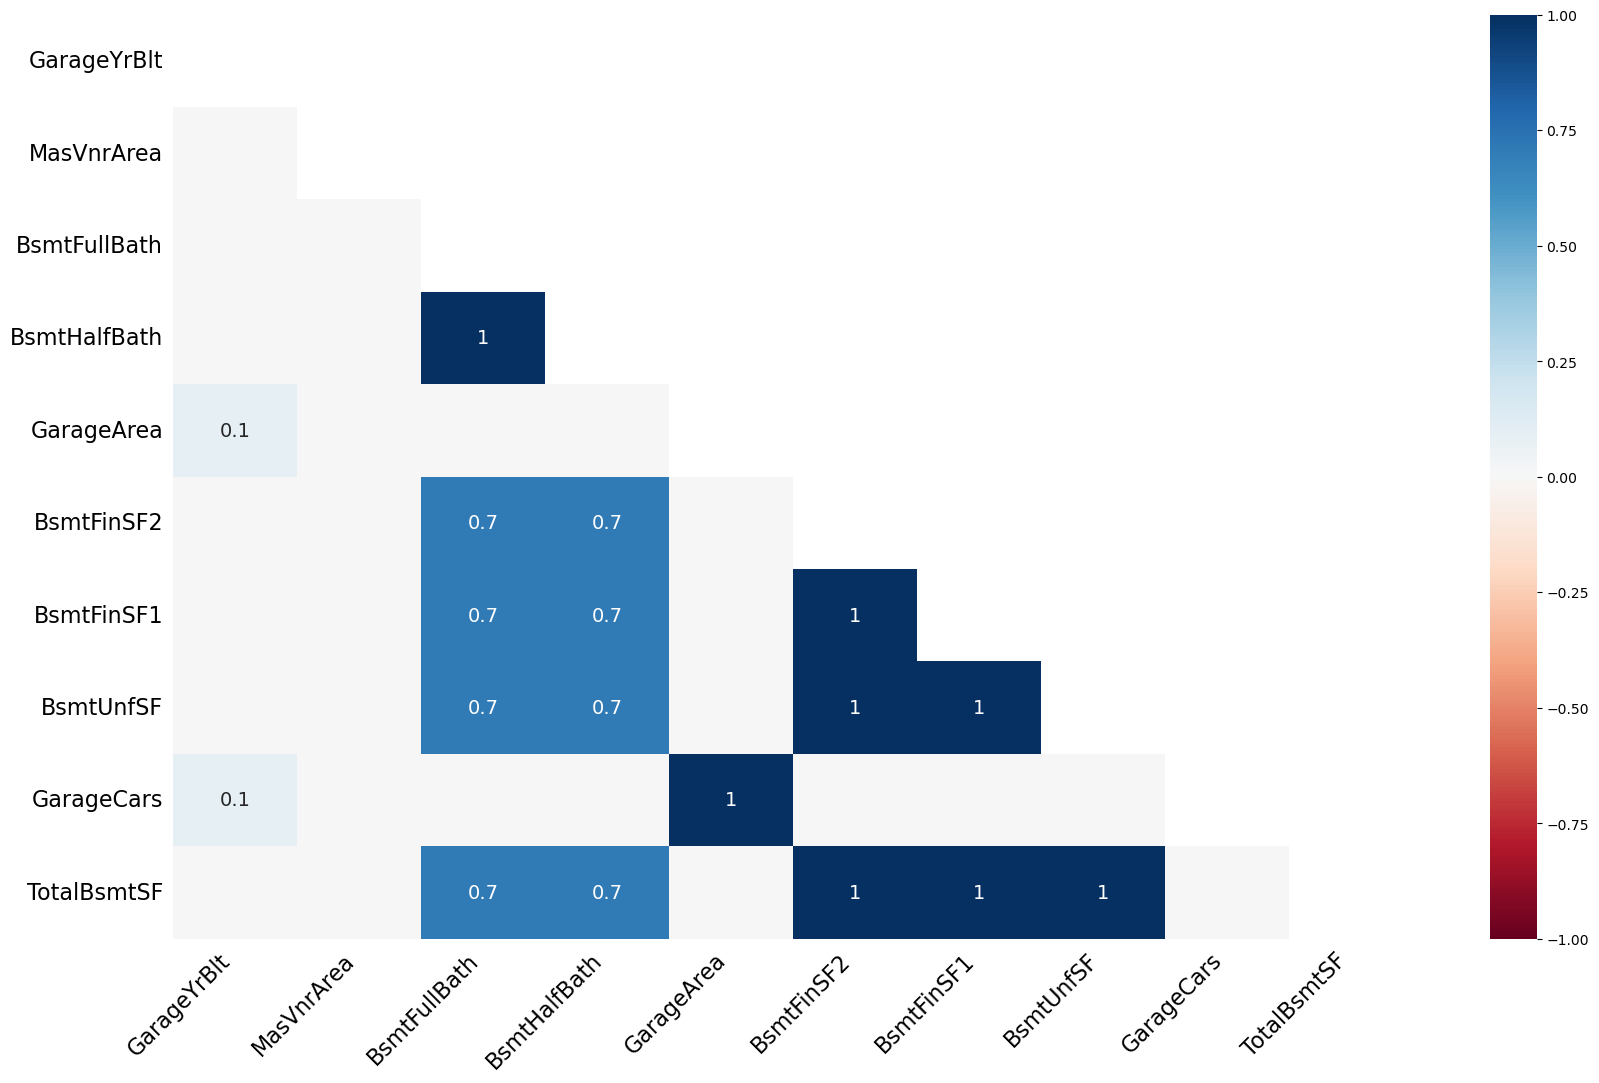

In [39]:
# mối tương quan giữa các giá trị bị thiếu trong các cột khác nhau
msno.heatmap(data[num_fill])

In [40]:
# => Việc thiếu dữ liệu không phải ngẫu nhiên, nếu dữ liệu bị mất sẽ tạo ra sai lệch cho mô hình.

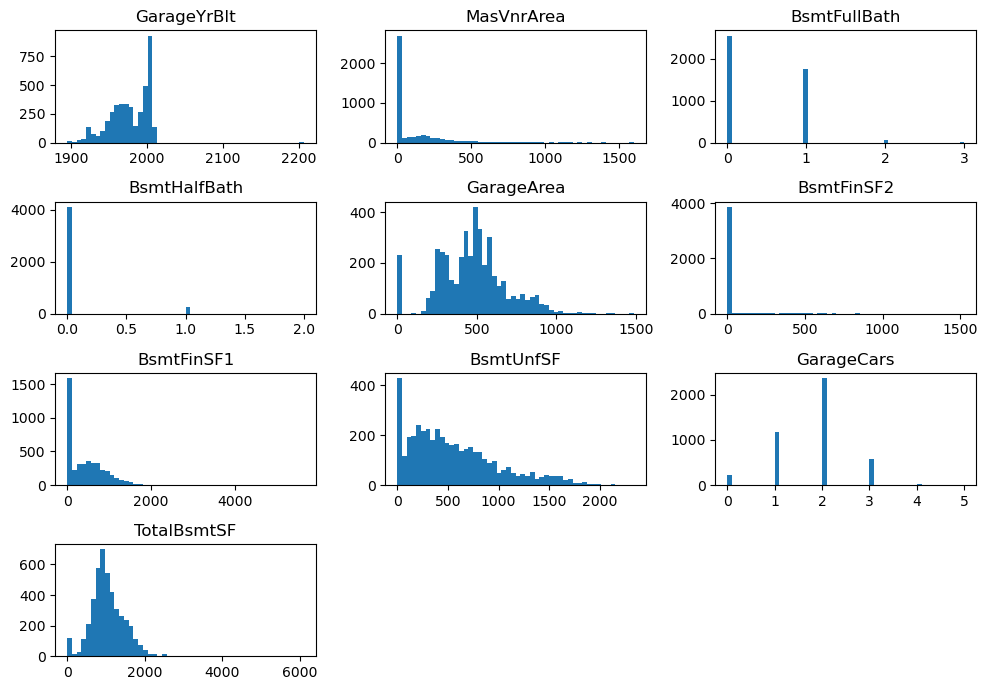

In [41]:
fig = plt.figure(figsize=(10, 7))

ncols = 3
nrows = int(np.ceil(data[num_fill].shape[1] / ncols))

for i, c in enumerate(data[num_fill].columns):
    ax = fig.add_subplot(nrows, ncols, i + 1)
    data[num_fill][c].plot.hist(bins=50, ax=ax)
    ax.set_title(c)
    ax.set_ylabel(None)

plt.tight_layout()
plt.show()

In [42]:
#Xử lý nan str

In [43]:
data[cate_fill].head()

,GarageCond,GarageFinish,GarageQual,GarageType,BsmtExposure,BsmtCond,BsmtQual,BsmtFinType2,BsmtFinType1,MSZoning,Utilities,Functional,KitchenQual,Electrical,SaleType,Exterior1st,Exterior2nd
0,TA,Fin,TA,Attchd,Gd,Gd,TA,Unf,BLQ,RL,AllPub,Typ,TA,SBrkr,WD,BrkFace,Plywood
1,TA,Unf,TA,Attchd,No,TA,TA,LwQ,Rec,RH,AllPub,Typ,TA,SBrkr,WD,VinylSd,VinylSd
2,TA,Unf,TA,Attchd,No,TA,TA,Unf,ALQ,RL,AllPub,Typ,Gd,SBrkr,WD,Wd Sdng,Wd Sdng
3,TA,Fin,TA,Attchd,No,TA,TA,Unf,ALQ,RL,AllPub,Typ,Ex,SBrkr,WD,BrkFace,BrkFace
4,TA,Fin,TA,Attchd,No,TA,Gd,Unf,GLQ,RL,AllPub,Typ,TA,SBrkr,WD,VinylSd,VinylSd


In [44]:
train[cate_fill]

,GarageCond,GarageFinish,GarageQual,GarageType,BsmtExposure,BsmtCond,BsmtQual,BsmtFinType2,BsmtFinType1,MSZoning,Utilities,Functional,KitchenQual,Electrical,SaleType,Exterior1st,Exterior2nd
0,TA,Fin,TA,Attchd,Gd,Gd,TA,Unf,BLQ,RL,AllPub,Typ,TA,SBrkr,WD,BrkFace,Plywood
1,TA,Unf,TA,Attchd,No,TA,TA,LwQ,Rec,RH,AllPub,Typ,TA,SBrkr,WD,VinylSd,VinylSd
2,TA,Unf,TA,Attchd,No,TA,TA,Unf,ALQ,RL,AllPub,Typ,Gd,SBrkr,WD,Wd Sdng,Wd Sdng
3,TA,Fin,TA,Attchd,No,TA,TA,Unf,ALQ,RL,AllPub,Typ,Ex,SBrkr,WD,BrkFace,BrkFace
4,TA,Fin,TA,Attchd,No,TA,Gd,Unf,GLQ,RL,AllPub,Typ,TA,SBrkr,WD,VinylSd,VinylSd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,TA,Unf,TA,Detchd,Av,TA,TA,Unf,GLQ,RL,AllPub,Typ,TA,SBrkr,WD,HdBoard,HdBoard
2926,TA,Unf,TA,Attchd,Av,TA,Gd,ALQ,BLQ,RL,AllPub,Typ,TA,SBrkr,WD,HdBoard,HdBoard
2927,NaN,NaN,NaN,NaN,Av,TA,Gd,Unf,GLQ,RL,AllPub,Typ,TA,SBrkr,WD,HdBoard,Wd Shng
2928,TA,RFn,TA,Attchd,Av,TA,Gd,LwQ,ALQ,RL,AllPub,Typ,TA,SBrkr,WD,HdBoard,HdBoard


In [45]:
train[cate_fill] = train[cate_fill].fillna(train[cate_fill].mode().iloc[0])
test[cate_fill] = test[cate_fill].fillna(test[cate_fill].mode().iloc[0])

In [46]:
#còn biến LotFrontage tỉ lệ nan ~16%

In [47]:
m = data[data['LotFrontage'].isna()]
n = data[~data['LotFrontage'].isna()]

In [48]:
m.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemod/Add,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,YearRemodAdd
count,717.000000,0.0,717.000000,717.000000,717.000000,717.000000,490.000000,707.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,702.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,717.000000,227.000000
mean,55.041841,NaN,12073.078103,6.114365,5.503487,1975.817294,1983.365306,113.964639,521.260809,65.330544,471.736402,1058.327755,1194.210600,363.675035,2.629010,1560.514644,0.496513,0.073919,1.622036,0.461646,2.935844,1.036262,6.490934,0.767085,1979.169516,1.889819,496.269177,118.301255,49.493724,20.414226,3.046025,16.114365,1.029289,67.615063,6.086471,2007.806137,1983.259912
std,36.799296,NaN,11124.249053,1.195091,1.142892,22.602005,18.089168,179.506240,406.969259,205.639080,403.855980,388.604997,352.730564,467.122523,34.254334,497.993142,0.532782,0.261822,0.582055,0.531409,0.854702,0.201451,1.497293,0.678998,19.802046,0.636742,175.038771,151.543773,62.488582,64.586415,26.168115,56.090517,27.561115,686.387415,2.602276,1.269569,18.538607
min,20.000000,NaN,1533.000000,1.000000,1.000000,1900.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,530.000000,0.000000,0.000000,660.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1900.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,1950.000000
25%,20.000000,NaN,8145.000000,5.000000,5.000000,1963.000000,1967.000000,0.000000,149.000000,0.000000,186.000000,848.000000,924.000000,0.000000,0.000000,1160.000000,0.000000,0.000000,1.000000,0.000000,3.000000,1.000000,5.000000,0.000000,1966.000000,2.000000,400.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,1967.000000
50%,60.000000,NaN,10382.000000,6.000000,5.000000,1977.000000,1987.000000,0.000000,544.000000,0.000000,350.000000,1024.000000,1143.000000,0.000000,0.000000,1491.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,488.000000,81.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,1991.000000
75%,70.000000,NaN,12800.000000,7.000000,6.000000,1996.000000,2000.000000,180.000000,800.000000,0.000000,675.000000,1281.000000,1418.000000,783.000000,0.000000,1850.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,1997.000000,2.000000,578.000000,192.000000,76.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,2009.000000,2000.000000
max,190.000000,NaN,164660.000000,10.000000,9.000000,2009.000000,2010.000000,1159.000000,1733.000000,1526.000000,1969.000000,3200.000000,3228.000000,1721.000000,528.000000,3447.000000,2.000000,1.000000,4.000000,2.000000,6.000000,2.000000,13.000000,3.000000,2009.000000,4.000000,1356.000000,1424.000000,324.000000,584.000000,290.000000,490.000000,738.000000,15500.000000,12.000000,2010.000000,2009.000000


In [49]:
n.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemod/Add,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,YearRemodAdd
count,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,2440.000000,3644.000000,3670.000000,3670.000000,3670.000000,3670.000000,3672.000000,3672.000000,3672.000000,3672.000000,3668.000000,3668.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3450.000000,3670.000000,3670.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,3672.000000,1232.000000
mean,57.841776,69.008442,9641.386166,6.084695,5.571078,1970.485839,1984.447541,99.084797,425.906540,47.823978,574.388828,1048.119346,1151.590142,326.175926,4.626362,1482.392429,0.419847,0.060251,1.557462,0.362745,2.838235,1.045207,6.410675,0.559368,1977.756812,1.742507,468.218256,88.729031,47.460784,24.008170,2.186819,16.402233,2.282135,50.312636,6.196895,2007.779139,1983.737013
std,43.713553,23.037371,5850.065112,1.459399,1.105871,31.502471,21.372267,178.348752,462.760477,164.147894,443.313149,450.943605,401.173770,417.046251,47.459832,498.209231,0.524667,0.244762,0.547368,0.495368,0.822244,0.214241,1.562352,0.636033,26.887441,0.786169,222.498294,120.826653,68.963301,65.284232,23.086821,56.297356,35.099142,567.477919,2.739217,1.319745,21.580085
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,1950.000000
25%,20.000000,58.000000,7200.000000,5.000000,5.000000,1950.000000,1964.000000,0.000000,0.000000,0.000000,227.250000,780.000000,864.000000,0.000000,0.000000,1118.750000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1958.000000,1.000000,308.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,1962.000000
50%,50.000000,68.000000,9254.000000,6.000000,5.000000,1972.000000,1994.000000,0.000000,330.000000,0.000000,483.000000,981.500000,1072.000000,0.000000,0.000000,1430.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,0.000000,1979.000000,2.000000,477.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,1993.000000
75%,70.000000,80.000000,11195.000000,7.000000,6.000000,2003.000000,2004.000000,157.000000,724.000000,0.000000,817.000000,1308.000000,1380.000000,677.000000,0.000000,1717.250000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2003.000000,2.000000,576.000000,167.000000,69.250000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,2005.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,870.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,2010.000000


In [50]:
# Sau khi phân tích cột LotFrontage không có mối quan hệ tuyến tính hoặc mối tương quan rõ ràng, trực tiếp với toàn bộ các đặc trưng (features) khác trong bảng dữ liệu

In [51]:
cols = data.select_dtypes(include=['int64', 'float64']).corr()['LotFrontage']
strongcorr1 = cols[abs(cols) >0.4]
print(strongcorr1)

MSSubClass    -0.429952
LotFrontage    1.000000
LotArea        0.525336
1stFlrSF       0.458437
Name: LotFrontage, dtype: float64


In [52]:
lot_mean = train['LotFrontage'].mean()
lot_mean1 = test['LotFrontage'].mean()
train['LotFrontage'] = train['LotFrontage'].fillna(lot_mean)
test['LotFrontage'] = test['LotFrontage'].fillna(lot_mean1)

In [53]:
for c in num_fill:
    train[c] = train[c].fillna(train[c].mean())
    test[c] = test[c].fillna(test[c].mean())

In [54]:
train[num_fill].info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GarageYrBlt   2930 non-null   float64
 1   MasVnrArea    2930 non-null   float64
 2   BsmtFullBath  2930 non-null   float64
 3   BsmtHalfBath  2930 non-null   float64
 4   GarageArea    2930 non-null   float64
 5   BsmtFinSF2    2930 non-null   float64
 6   BsmtFinSF1    2930 non-null   float64
 7   BsmtUnfSF     2930 non-null   float64
 8   GarageCars    2930 non-null   float64
 9   TotalBsmtSF   2930 non-null   float64
dtypes: float64(10)
memory usage: 229.0 KB


In [55]:
test[num_fill].info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   GarageYrBlt   1459 non-null   float64
 1   MasVnrArea    1459 non-null   float64
 2   BsmtFullBath  1459 non-null   float64
 3   BsmtHalfBath  1459 non-null   float64
 4   GarageArea    1459 non-null   float64
 5   BsmtFinSF2    1459 non-null   float64
 6   BsmtFinSF1    1459 non-null   float64
 7   BsmtUnfSF     1459 non-null   float64
 8   GarageCars    1459 non-null   float64
 9   TotalBsmtSF   1459 non-null   float64
dtypes: float64(10)
memory usage: 114.1 KB


In [56]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2930 non-null   int64  
 1   MSSubClass     2930 non-null   int64  
 2   MSZoning       2930 non-null   str    
 3   LotFrontage    2930 non-null   float64
 4   LotArea        2930 non-null   int64  
 5   Street         2930 non-null   str    
 6   Alley          2930 non-null   str    
 7   LotShape       2930 non-null   str    
 8   LandContour    2930 non-null   str    
 9   Utilities      2930 non-null   str    
 10  LotConfig      2930 non-null   str    
 11  LandSlope      2930 non-null   str    
 12  Neighborhood   2930 non-null   str    
 13  Condition1     2930 non-null   str    
 14  Condition2     2930 non-null   str    
 15  BldgType       2930 non-null   str    
 16  HouseStyle     2930 non-null   str    
 17  OverallQual    2930 non-null   int64  
 18  OverallCond    2930

In [57]:
train = train.rename(columns={'YearRemod/Add':'YearRemodAdd'})
data = pd.concat([train, test], axis=0).drop('SalePrice', axis=1).reset_index(drop=True)
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,20,RL,141.0,31770,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.000000,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,None,None,None,0,5,2010,WD,Normal
1,2,20,RH,80.0,11622,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,None,Attchd,1961.000000,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,None,MnPrv,None,0,6,2010,WD,Normal
2,3,20,RL,81.0,14267,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,None,Attchd,1958.000000,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,None,None,Gar2,12500,6,2010,WD,Normal
3,4,20,RL,93.0,11160,Pave,None,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.000000,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,None,None,None,0,4,2010,WD,Normal
4,5,60,RL,74.0,13830,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.000000,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,None,MnPrv,None,0,3,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4384,2915,160,RM,21.0,1936,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,None,Attchd,1977.721217,Unf,0.0,0.0,TA,TA,Y,0,0,0,0,0,0,None,None,None,0,6,2006,WD,Normal
4385,2916,160,RM,21.0,1894,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,None,CarPort,1970.000000,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,None,None,None,0,4,2006,WD,Abnorml
4386,2917,20,RL,160.0,20000,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.000000,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,None,None,None,0,9,2006,WD,Abnorml
4387,2918,85,RL,62.0,10441,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Mitchel

In [58]:
data.isnull().sum().sum()

np.int64(2669)

<h1 style="text-align: center; color: blue;">
    Ràng buộc kiểu dữ liệu
</h1>

In [59]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4389 entries, 0 to 4388
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             4389 non-null   int64  
 1   MSSubClass     4389 non-null   int64  
 2   MSZoning       4389 non-null   str    
 3   LotFrontage    4389 non-null   float64
 4   LotArea        4389 non-null   int64  
 5   Street         4389 non-null   str    
 6   Alley          4389 non-null   str    
 7   LotShape       4389 non-null   str    
 8   LandContour    4389 non-null   str    
 9   Utilities      4389 non-null   str    
 10  LotConfig      4389 non-null   str    
 11  LandSlope      4389 non-null   str    
 12  Neighborhood   4389 non-null   str    
 13  Condition1     4389 non-null   str    
 14  Condition2     4389 non-null   str    
 15  BldgType       4389 non-null   str    
 16  HouseStyle     4389 non-null   str    
 17  OverallQual    4389 non-null   int64  
 18  OverallCond    4389

In [60]:
data.select_dtypes(include = 'str').head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,BrkFace,Plywood,Stone,TA,TA,CBlock,TA,Gd,Gd,BLQ,Unf,GasA,Fa,Y,SBrkr,TA,Typ,Gd,Attchd,Fin,TA,TA,P,None,None,None,WD,Normal
1,RH,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,NaN,TA,TA,CBlock,TA,TA,No,Rec,LwQ,GasA,TA,Y,SBrkr,TA,Typ,None,Attchd,Unf,TA,TA,Y,None,MnPrv,None,WD,Normal
2,RL,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,TA,TA,CBlock,TA,TA,No,ALQ,Unf,GasA,TA,Y,SBrkr,Gd,Typ,None,Attchd,Unf,TA,TA,Y,None,None,Gar2,WD,Normal
3,RL,Pave,None,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,BrkFace,BrkFace,NaN,Gd,TA,CBlock,TA,TA,No,ALQ,Unf,GasA,Ex,Y,SBrkr,Ex,Typ,TA,Attchd,Fin,TA,TA,Y,None,None,None,WD,Normal
4,RL,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,NaN,TA,TA,PConc,Gd,TA,No,GLQ,Unf,GasA,Gd,Y,SBrkr,TA,Typ,TA,Attchd,Fin,TA,TA,Y,None,MnPrv,None,WD,Normal


In [61]:
cate = data.select_dtypes(include = 'str').columns.to_list()
data[cate] = data[cate].astype('category')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4389 entries, 0 to 4388
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             4389 non-null   int64   
 1   MSSubClass     4389 non-null   int64   
 2   MSZoning       4389 non-null   category
 3   LotFrontage    4389 non-null   float64 
 4   LotArea        4389 non-null   int64   
 5   Street         4389 non-null   category
 6   Alley          4389 non-null   category
 7   LotShape       4389 non-null   category
 8   LandContour    4389 non-null   category
 9   Utilities      4389 non-null   category
 10  LotConfig      4389 non-null   category
 11  LandSlope      4389 non-null   category
 12  Neighborhood   4389 non-null   category
 13  Condition1     4389 non-null   category
 14  Condition2     4389 non-null   category
 15  BldgType       4389 non-null   category
 16  HouseStyle     4389 non-null   category
 17  OverallQual    4389 non-null   int64   
 18 

In [62]:
data.select_dtypes(['int64','float64']).head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,1,20,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,0,0,1656,1.0,0.0,1,0,3,1,7,2,1960.0,2.0,528.0,210,62,0,0,0,0,0,5,2010
1,2,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,882.0,896,0,0,896,0.0,0.0,1,0,2,1,5,0,1961.0,1.0,730.0,140,0,0,0,120,0,0,6,2010
2,3,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,0,0,1329,0.0,0.0,1,1,3,1,6,0,1958.0,1.0,312.0,393,36,0,0,0,0,12500,6,2010
3,4,20,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,0,0,2110,1.0,0.0,2,1,3,1,8,2,1968.0,2.0,522.0,0,0,0,0,0,0,0,4,2010
4,5,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,928.0,928,701,0,1629,0.0,0.0,2,1,3,1,6,1,1997.0,2.0,482.0,212,34,0,0,0,0,0,3,2010


In [63]:
check_col = ['MSSubClass','OverallQual','OverallCond','YrSold','MoSold']
for c in check_col:
    print(data[c].value_counts().sort_index())

MSSubClass
20     1622
30      209
40        8
45       24
50      430
60      851
70      196
75       30
80      178
85       76
90      166
120     287
150       2
160     194
180      24
190      92
Name: count, dtype: int64
OverallQual
1        6
2       23
3       60
4      336
5     1253
6     1089
7      883
8      524
9      171
10      44
Name: count, dtype: int64
OverallCond
1      13
2      15
3      75
4     145
5    2478
6     812
7     575
8     216
9      60
Name: count, dtype: int64
YrSold
2006     930
2007    1057
2008     940
2009     957
2010     505
Name: count, dtype: int64
MoSold
1     187
2     214
3     358
4     417
5     585
6     755
7     661
8     344
9     256
10    257
11    206
12    149
Name: count, dtype: int64


In [64]:
data['MSSubClass'] = data['MSSubClass'].apply(str).astype('category')
data['YrSold'] = data['YrSold'].apply(str).astype('category')
data['MoSold'] = data['MoSold'].apply(str).astype('category')

<h1 style="text-align: center; color: blue;">
    Kiểm tra giá trị trùng lặp
</h1>

In [65]:
data[data.duplicated()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition


In [66]:
#Xử lý dữ liệu trong cột category

In [67]:
for c in cate:
    data[c] = data[c].str.lower().str.strip().astype('category')
data['SaleType'].value_counts()

SaleType
wd       3795
new       356
cod       131
conld      43
cwd        20
conli      13
conlw      11
oth        11
con         8
vwd         1
Name: count, dtype: int64

<h1 style="text-align: center; color: blue;">
    Phân tích các giá trị ngoại lai
</h1>

In [68]:
data.select_dtypes(['int64','float64']).describe()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal
count,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.00000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000
mean,1706.339713,69.010433,10038.634541,6.089542,5.560036,1971.356801,1984.065846,101.501997,441.490734,50.685428,557.61120,1049.787362,1158.552746,332.301891,4.300068,1495.154705,0.432384,0.062486,1.568011,0.378902,2.854181,1.043746,6.423787,0.593301,1977.995742,1.766583,472.802823,93.560036,47.792891,23.421053,2.327182,16.355206,2.077466,53.139212
std,808.203314,21.071671,7044.993407,1.419506,1.112151,30.290079,20.950010,177.826021,455.330740,171.672772,438.60947,441.231826,393.945098,425.798977,45.567449,498.953983,0.526465,0.247540,0.553630,0.502702,0.828321,0.212208,1.552027,0.647737,25.122538,0.765449,215.640082,126.808816,67.945124,65.176973,23.616631,56.257339,33.982520,588.495661
min,1.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.00000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1098.000000,60.000000,7424.000000,5.000000,5.000000,1953.000000,1965.000000,0.000000,0.000000,0.000000,219.00000,789.000000,875.000000,0.000000,0.000000,1124.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,319.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1828.000000,69.224590,9430.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,364.000000,0.000000,462.00000,988.000000,1082.000000,0.000000,0.000000,1440.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1978.132443,2.000000,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2376.000000,78.000000,11553.000000,7.000000,6.000000,2001.000000,2004.000000,162.000000,739.000000,0.000000,801.00000,1302.000000,1384.000000,695.000000,0.000000,1734.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,2930.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.00000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000


In [69]:
num_col = train.select_dtypes(['int64','float64'])
num_col.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,20,141.0,31770,6,5,1960,1960,112.0,639.0,0.0,441.0,1080.0,1656,0,0,1656,1.0,0.0,1,0,3,1,7,2,1960.0,2.0,528.0,210,62,0,0,0,0,0,5,2010,12.278398
1,2,20,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,882.0,896,0,0,896,0.0,0.0,1,0,2,1,5,0,1961.0,1.0,730.0,140,0,0,0,120,0,0,6,2010,11.561725
2,3,20,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,1329.0,1329,0,0,1329,0.0,0.0,1,1,3,1,6,0,1958.0,1.0,312.0,393,36,0,0,0,0,12500,6,2010,12.055256
3,4,20,93.0,11160,7,5,1968,1968,0.0,1065.0,0.0,1045.0,2110.0,2110,0,0,2110,1.0,0.0,2,1,3,1,8,2,1968.0,2.0,522.0,0,0,0,0,0,0,0,4,2010,12.404928
4,5,60,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,928.0,928,701,0,1629,0.0,0.0,2,1,3,1,6,1,1997.0,2.0,482.0,212,34,0,0,0,0,0,3,2010,12.154258


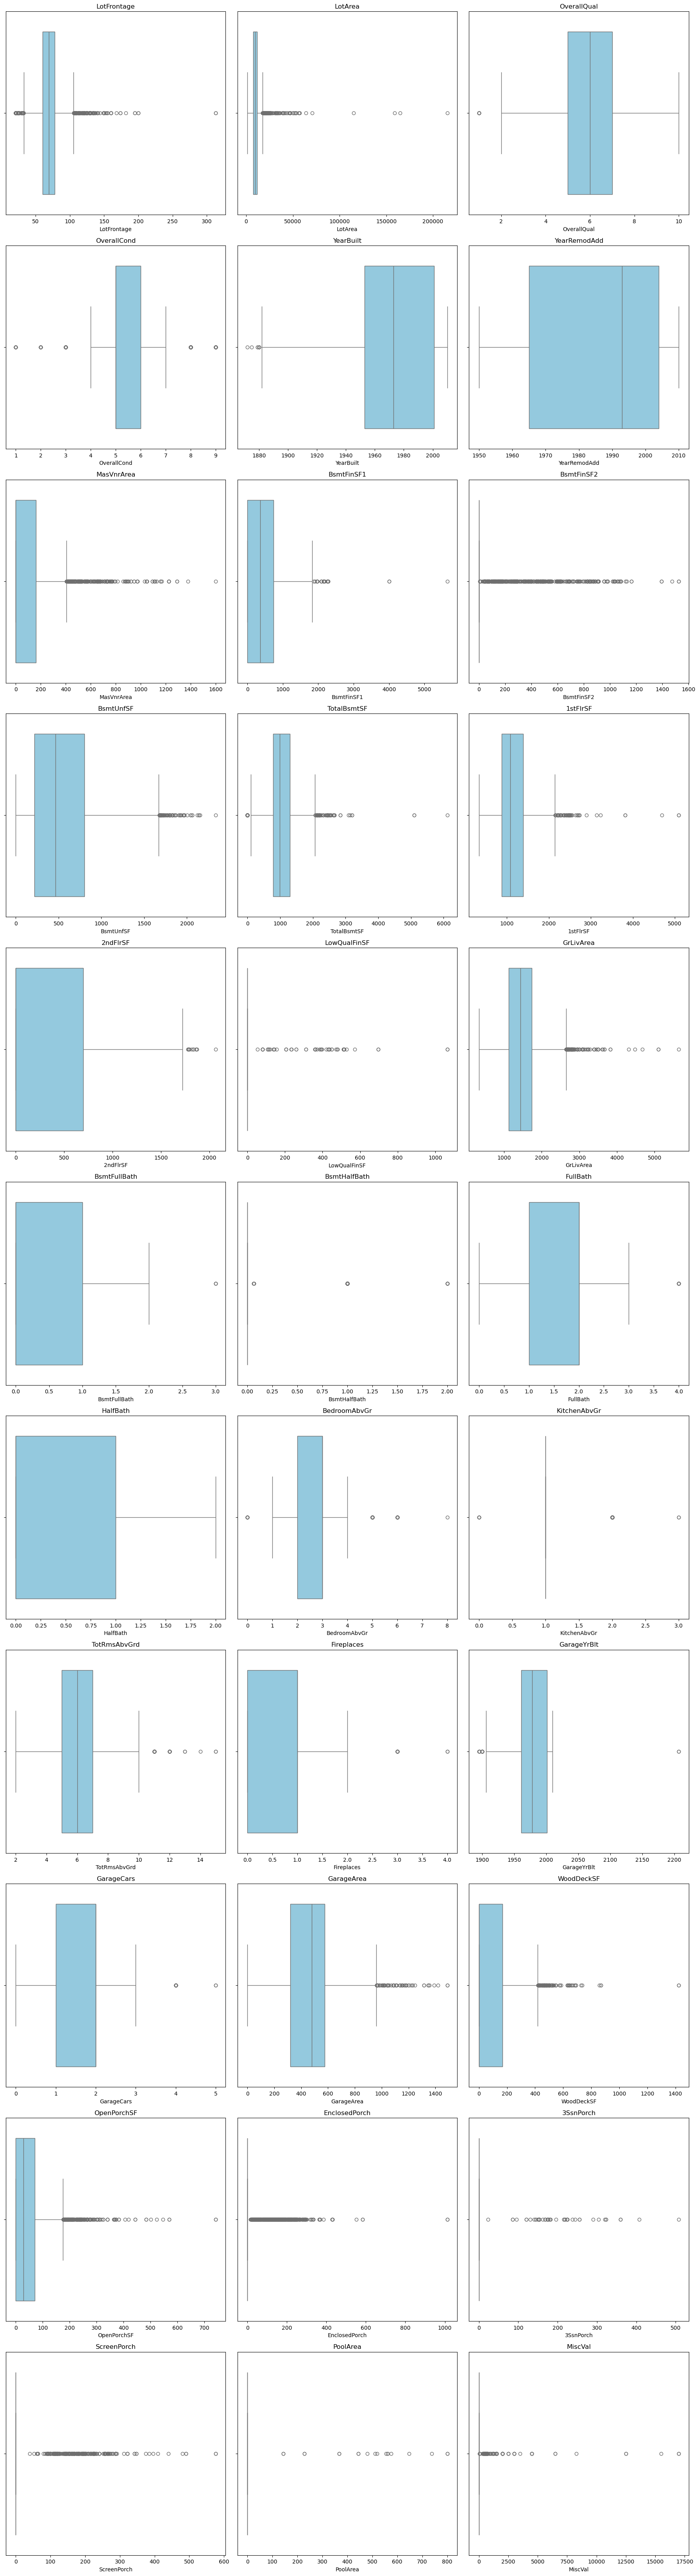

In [70]:
df_num = data.select_dtypes(include=['int64','float64']).drop(
    columns=['Id']
)

# Số subplot
ncols = 3
nrows = int(np.ceil(df_num.shape[1] / ncols))

# Tạo figure lớn
fig = plt.figure(figsize=(18, 6*nrows))

for i, col in enumerate(df_num.columns):
    ax = fig.add_subplot(nrows, ncols, i + 1)
    
    sns.boxplot(x=df_num[col], ax=ax, color='skyblue')
    ax.set_title(col, fontsize=12)

plt.tight_layout()
plt.show()

In [71]:
def doutlier(d, whisker_width=1.5):
    q25 = d.quantile(0.25)
    q75 = d.quantile(0.75)
    iqr = q75 - q25
    return d[(d > q75+whisker_width*iqr) | (d < q25-whisker_width*iqr)]

In [72]:
pd.DataFrame(doutlier(num_col, whisker_width=1.5).count().sort_values(ascending=False)).T

,EnclosedPorch,BsmtFinSF2,LotFrontage,ScreenPorch,OverallCond,MSSubClass,MasVnrArea,BsmtHalfBath,OpenPorchSF,KitchenAbvGr,LotArea,TotalBsmtSF,MiscVal,BedroomAbvGr,GrLivArea,WoodDeckSF,SalePrice,BsmtUnfSF,TotRmsAbvGrd,1stFlrSF,GarageArea,LowQualFinSF,3SsnPorch,GarageCars,BsmtFinSF1,Fireplaces,PoolArea,YearBuilt,GarageYrBlt,2ndFlrSF,FullBath,OverallQual,BsmtFullBath,Id,HalfBath,YearRemodAdd,MoSold,YrSold
0,459,352,261,256,252,208,203,177,159,134,127,123,103,78,75,67,60,56,51,43,42,40,37,17,15,13,13,9,9,8,4,4,2,0,0,0,0,0


In [73]:
#giữ lại các giá trị được xác định là outlier dropna dòng toàn nan
outlier = doutlier(num_col, whisker_width=1.5).dropna(how='all')
outlier

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,NaN,NaN,141.0,31770.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.0,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12500.0,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2110.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2922,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2924,NaN,NaN,160.0,20000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,474.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,324.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2927,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,700.0,NaN,NaN,NaN


In [74]:
#Các hàng saleprice bị outlier có liên quan đến các cột khác cũng bị outlier
outprice = outlier[outlier['SalePrice'].notnull()]
outprice.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
15,NaN,NaN,NaN,53504.0,NaN,NaN,NaN,NaN,603.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3279.0,NaN,NaN,NaN,NaN,NaN,NaN,12.0,NaN,NaN,NaN,NaN,503.0,NaN,NaN,NaN,210.0,NaN,NaN,NaN,NaN,13.195616
44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,760.0,2188.0,NaN,NaN,2330.0,2364.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.323929
46,NaN,NaN,110.0,NaN,NaN,NaN,NaN,NaN,1095.0,NaN,NaN,NaN,2846.0,2696.0,NaN,NaN,2696.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.122365
181,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.456419
206,NaN,190.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3500.0,NaN,NaN,10.915107


In [75]:
#In ra số lg outlier mỗi cột tại outlier của cột saleprice
pd.DataFrame(outprice.count().sort_values(ascending=False)).T

,SalePrice,MasVnrArea,TotalBsmtSF,GrLivArea,1stFlrSF,OverallCond,LotFrontage,EnclosedPorch,ScreenPorch,TotRmsAbvGrd,BsmtFinSF1,OpenPorchSF,LotArea,GarageArea,2ndFlrSF,BsmtUnfSF,OverallQual,WoodDeckSF,MiscVal,PoolArea,LowQualFinSF,BsmtFinSF2,GarageCars,MSSubClass,Fireplaces,KitchenAbvGr,BsmtHalfBath,BedroomAbvGr,GarageYrBlt,Id,HalfBath,FullBath,BsmtFullBath,YearRemodAdd,YearBuilt,3SsnPorch,MoSold,YrSold
0,60,25,22,16,15,13,12,12,12,9,8,8,8,7,4,3,3,2,2,2,2,2,1,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0


In [76]:
#Số lượng outlier của các cột tương quan mạnh với saleprice
x = strongcol.index
x = x.str.replace('YearRemod/Add', 'YearRemodAdd')
doutlier(num_col, whisker_width=1.5)[x].count().sort_values(ascending=False)

TotalBsmtSF     123
GrLivArea        75
SalePrice        60
1stFlrSF         43
GarageArea       42
GarageCars       17
YearBuilt         9
GarageYrBlt       9
OverallQual       4
FullBath          4
YearRemodAdd      0
dtype: int64

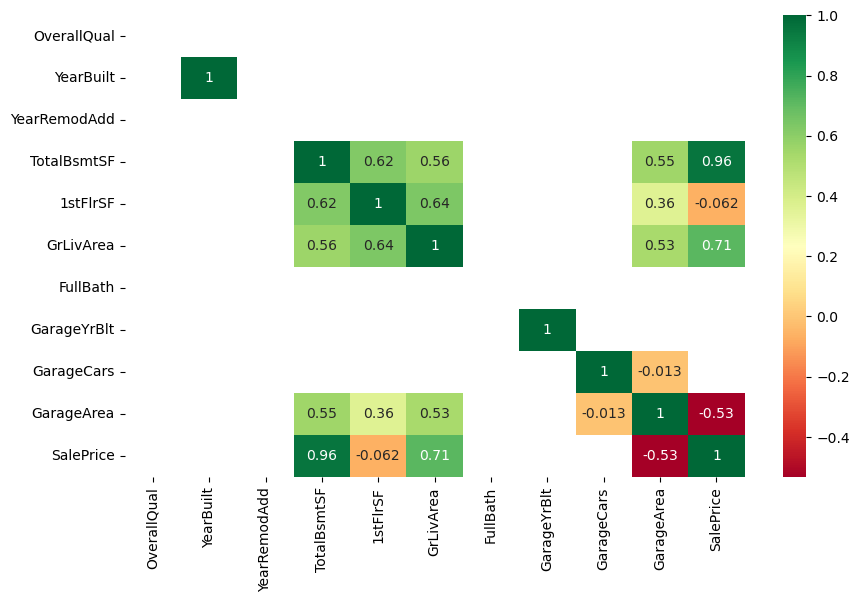

In [77]:
plt.figure(figsize=(10,6))
g = sns.heatmap(outlier[x].corr(),annot=True,cmap="RdYlGn")

In [78]:
#Có nhiều giá trị ngoại lệ trong tập dữ liệu, nhưng các giá trị ngoại lệ của đặc trưng chính có tương quan cao với các giá trị ngoại lệ của biến mục tiêu 
# => Sử dụng thang logarit để đảm bảo không bỏ sót dữ liệu

<h1 style="text-align: center; color: blue;">
    Tạo feature mới
</h1>

In [79]:
#Tong dien tich toa nha
data['ToTalSF'] = data['TotalBsmtSF'] + data['1stFlrSF'] + data['2ndFlrSF']
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,ToTalSF
0,1,20,rl,141.0,31770,pave,none,ir1,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,6,5,1960,1960,hip,compshg,brkface,plywood,stone,112.0,ta,ta,cblock,ta,gd,gd,blq,639.0,unf,0.0,441.0,1080.0,gasa,fa,y,sbrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,ta,7,typ,2,gd,attchd,1960.0,fin,2.0,528.0,ta,ta,p,210,62,0,0,0,0,none,none,none,0,5,2010,wd,normal,2736.0
1,2,20,rh,80.0,11622,pave,none,reg,lvl,allpub,inside,gtl,names,feedr,norm,1fam,1story,5,6,1961,1961,gable,compshg,vinylsd,vinylsd,NaN,0.0,ta,ta,cblock,ta,ta,no,rec,468.0,lwq,144.0,270.0,882.0,gasa,ta,y,sbrkr,896,0,0,896,0.0,0.0,1,0,2,1,ta,5,typ,0,none,attchd,1961.0,unf,1.0,730.0,ta,ta,y,140,0,0,0,120,0,none,mnprv,none,0,6,2010,wd,normal,1778.0
2,3,20,rl,81.0,14267,pave,none,ir1,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,6,6,1958,1958,hip,compshg,wd sdng,wd sdng,brkface,108.0,ta,ta,cblock,ta,ta,no,alq,923.0,unf,0.0,406.0,1329.0,gasa,ta,y,sbrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,gd,6,typ,0,none,attchd,1958.0,unf,1.0,312.0,ta,ta,y,393,36,0,0,0,0,none,none,gar2,12500,6,2010,wd,normal,2658.0
3,4,20,rl,93.0,11160,pave,none,reg,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,7,5,1968,1968,hip,compshg,brkface,brkface,NaN,0.0,gd,ta,cblock,ta,ta,no,alq,1065.0,unf,0.0,1045.0,2110.0,gasa,ex,y,sbrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,ex,8,typ,2,ta,attchd,1968.0,fin,2.0,522.0,ta,ta,y,0,0,0,0,0,0,none,none,none,0,4,2010,wd,normal,4220.0
4,5,60,rl,74.0,13830,pave,none,ir1,lvl,allpub,inside,gtl,gilbert,norm,norm,1fam,2story,5,5,1997,1998,gable,compshg,vinylsd,vinylsd,NaN,0.0,ta,ta,pconc,gd,ta,no,glq,791.0,unf,0.0,137.0,928.0,gasa,gd,y,sbrkr,928,701,0,1629,0.0,0.0,2,1,3,1,ta,6,typ,1,ta,attchd,1997.0,fin,2.0,482.0,ta,ta,y,212,34,0,0,0,0,none,mnprv,none,0,3,2010,wd,normal,2557.0


In [80]:
data[data['HalfBath'] == 1].head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,ToTalSF
2,3,20,rl,81.0,14267,pave,none,ir1,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,6,6,1958,1958,hip,compshg,wd sdng,wd sdng,brkface,108.0,ta,ta,cblock,ta,ta,no,alq,923.0,unf,0.0,406.0,1329.0,gasa,ta,y,sbrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,gd,6,typ,0,none,attchd,1958.0,unf,1.0,312.0,ta,ta,y,393,36,0,0,0,0,none,none,gar2,12500,6,2010,wd,normal,2658.0
3,4,20,rl,93.0,11160,pave,none,reg,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,7,5,1968,1968,hip,compshg,brkface,brkface,NaN,0.0,gd,ta,cblock,ta,ta,no,alq,1065.0,unf,0.0,1045.0,2110.0,gasa,ex,y,sbrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,ex,8,typ,2,ta,attchd,1968.0,fin,2.0,522.0,ta,ta,y,0,0,0,0,0,0,none,none,none,0,4,2010,wd,normal,4220.0


In [81]:
#Tong so Wc
#half bath là chỉ đc 1/2 cái WC(phòng tắm phụ ko đầy đủ bồn tắm...)-> số halfbath*1/2
data['TotalBath'] = data['BsmtFullBath'] + data['FullBath'] + 1/2*data['HalfBath'] + 1/2*data['BsmtHalfBath']
data['TotalBath'].value_counts()

TotalBath
2.000000    1357
2.500000     823
1.000000     656
3.000000     570
1.500000     457
3.500000     432
4.000000      49
4.500000      27
7.000000       6
5.000000       5
6.000000       3
1.461919       1
3.961919       1
1.467056       1
3.967056       1
Name: count, dtype: int64

In [82]:
#Tổng diện tích hiên nhà
data['TotalPorchSF'] = (data['OpenPorchSF'] + data['3SsnPorch'] + data['EnclosedPorch'] + data['ScreenPorch'] + data['WoodDeckSF'])

In [83]:
#Diện tích trung bình 
data["SqFtPerRoom"] = data["GrLivArea"] / (data["TotRmsAbvGrd"] +  data["FullBath"] + data["HalfBath"] +data["KitchenAbvGr"])
data['SqFtPerRoom'].describe()

count    4389.000000
mean      157.129938
std        27.879052
min        81.400000
25%       137.142857
50%       154.222222
75%       172.333333
max       352.625000
Name: SqFtPerRoom, dtype: float64

In [84]:
#Tổng thể chất lượng nhà
data['TotalHomeQuality'] = data['OverallQual'] + data['OverallCond']
data['TotalHomeQuality'].describe()

count    4389.000000
mean       11.649578
std         1.717984
min         2.000000
25%        11.000000
50%        12.000000
75%        13.000000
max        19.000000
Name: TotalHomeQuality, dtype: float64

In [85]:
#Tổng S các tầng
data["HighQualSF"] = data["1stFlrSF"] + data["2ndFlrSF"]

In [86]:
#Tổng diện tích tầng hầm đã hoàn thiện
data['TotalFinishBsmtSF'] = data['BsmtFinSF1'] + data['BsmtFinSF2']
#Ktra lại xem có bằng tổng diện tích tầng hầm không
check = (data['TotalBsmtSF'] != (data['TotalFinishBsmtSF']  +  data['BsmtUnfSF']))
data[check]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,ToTalSF,TotalBath,TotalPorchSF,SqFtPerRoom,TotalHomeQuality,HighQualSF,TotalFinishBsmtSF
1341,1342,20,rm,99.0,5940,pave,none,ir1,lvl,allpub,fr3,gtl,brkside,feedr,norm,1fam,1story,4,7,1946,1950,gable,compshg,metalsd,cblock,NaN,0.0,ta,ta,pconc,ta,ta,no,glq,442.629566,unf,49.722431,559.262547,1051.614544,gasa,ta,y,fusea,896,0,0,896,0.431352,0.061134,1,0,2,1,ta,4,typ,0,none,detchd,1946.0,unf,1.0,280.0,ta,ta,y,0,0,0,0,0,0,none,mnprv,none,0,4,2008,conld,abnorml,1947.614544,1.461919,0,149.333333,11,896,492.351997


In [87]:
data['HouseStyle'].value_counts()

HouseStyle
1story    2226
2story    1300
1.5fin     474
slvl       191
sfoyer     129
2.5unf      37
1.5unf      24
2.5fin       8
Name: count, dtype: int64

In [88]:
data['HasPool'] = (data['PoolArea'] > 0).astype(int)
data['HasFỉreplace'] = (data['Fireplaces'] > 0).astype(int)
data['HasGarage'] = (data['GarageArea'] > 0).astype(int)
data['HasHouseLevel2'] = (data['2ndFlrSF'] > 0).astype(int)
data['HasBmt'] = (data['TotalBsmtSF'] > 0).astype(int)

In [89]:
for x in ['HasPool','HasFỉreplace','HasGarage','HasHouseLevel2','HasBmt']:
    data[x]= data[x].astype('category')

In [90]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,ToTalSF,TotalBath,TotalPorchSF,SqFtPerRoom,TotalHomeQuality,HighQualSF,TotalFinishBsmtSF,HasPool,HasFỉreplace,HasGarage,HasHouseLevel2,HasBmt
0,1,20,rl,141.0,31770,pave,none,ir1,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,6,5,1960,1960,hip,compshg,brkface,plywood,stone,112.0,ta,ta,cblock,ta,gd,gd,blq,639.0,unf,0.0,441.0,1080.0,gasa,fa,y,sbrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,ta,7,typ,2,gd,attchd,1960.0,fin,2.0,528.0,ta,ta,p,210,62,0,0,0,0,none,none,none,0,5,2010,wd,normal,2736.0,2.0,272,184.000000,11,1656,639.0,0,1,1,0,1
1,2,20,rh,80.0,11622,pave,none,reg,lvl,allpub,inside,gtl,names,feedr,norm,1fam,1story,5,6,1961,1961,gable,compshg,vinylsd,vinylsd,NaN,0.0,ta,ta,cblock,ta,ta,no,rec,468.0,lwq,144.0,270.0,882.0,gasa,ta,y,sbrkr,896,0,0,896,0.0,0.0,1,0,2,1,ta,5,typ,0,none,attchd,1961.0,unf,1.0,730.0,ta,ta,y,140,0,0,0,120,0,none,mnprv,none,0,6,2010,wd,normal,1778.0,1.0,260,128.000000,11,896,612.0,0,0,1,0,1
2,3,20,rl,81.0,14267,pave,none,ir1,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,6,6,1958,1958,hip,compshg,wd sdng,wd sdng,brkface,108.0,ta,ta,cblock,ta,ta,no,alq,923.0,unf,0.0,406.0,1329.0,gasa,ta,y,sbrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,gd,6,typ,0,none,attchd,1958.0,unf,1.0,312.0,ta,ta,y,393,36,0,0,0,0,none,none,gar2,12500,6,2010,wd,normal,2658.0,1.5,429,147.666667,12,1329,923.0,0,0,1,0,1
3,4,20,rl,93.0,11160,pave,none,reg,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,7,5,1968,1968,hip,compshg,brkface,brkface,NaN,0.0,gd,ta,cblock,ta,ta,no,alq,1065.0,unf,0.0,1045.0,2110.0,gasa,ex,y,sbrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,ex,8,typ,2,ta,attchd,1968.0,fin,2.0,522.0,ta,ta,y,0,0,0,0,0,0,none,none,none,0,4,2010,wd,normal,4220.0,3.5,0,175.833333,12,2110,1065.0,0,1,1,0,1
4,5,60,rl,74.0,13830,pave,none,ir1,lvl,allpub,inside,gtl,gilbert,norm,norm,1fam,2story,5,5,1997,1998,gable,compshg,vinylsd,vinylsd,NaN,0.0,ta,ta,pconc,gd,ta,no,glq,791.0,unf,0.0,137.0,928.0,gasa,gd,y,sbrkr,928,701,0,1629,0.0,0.0,2,1,3,1,ta,6,typ,1,ta,attchd,1997.0,fin,2.0,482.0,ta,ta,y,212,34,0,0,0,0,none,mnprv,none,0,3,2010,wd,normal,2557.0,2.5,246,162.900000,10,1629,791.0,0,1,1,1,1


<h1 style="text-align: center; color: blue;">
    Fix dữ liệu các cột khi bị lệch
</h1>

In [91]:
data.describe()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,ToTalSF,TotalBath,TotalPorchSF,SqFtPerRoom,TotalHomeQuality,HighQualSF,TotalFinishBsmtSF
count,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.00000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000
mean,1706.339713,69.010433,10038.634541,6.089542,5.560036,1971.356801,1984.065846,101.501997,441.490734,50.685428,557.61120,1049.787362,1158.552746,332.301891,4.300068,1495.154705,0.432384,0.062486,1.568011,0.378902,2.854181,1.043746,6.423787,0.593301,1977.995742,1.766583,472.802823,93.560036,47.792891,23.421053,2.327182,16.355206,2.077466,53.139212,2540.641999,2.221089,183.456368,157.129938,11.649578,1490.854637,492.176162
std,808.203314,21.071671,7044.993407,1.419506,1.112151,30.290079,20.950010,177.826021,455.330740,171.672772,438.60947,441.231826,393.945098,425.798977,45.567449,498.953983,0.526465,0.247540,0.553630,0.502702,0.828321,0.212208,1.552027,0.647737,25.122538,0.765449,215.640082,126.808816,67.945124,65.176973,23.616631,56.257339,33.982520,588.495661,798.226633,0.815683,160.997355,27.879052,1.717984,497.268549,477.540448
min,1.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.00000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,1.000000,0.000000,81.400000,2.000000,334.000000,0.000000
25%,1098.000000,60.000000,7424.000000,5.000000,5.000000,1953.000000,1965.000000,0.000000,0.000000,0.000000,219.00000,789.000000,875.000000,0.000000,0.000000,1124.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1961.000000,1.000000,319.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1996.000000,1.500000,49.000000,137.142857,11.000000,1119.000000,0.000000
50%,1828.000000,69.224590,9430.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,364.000000,0.000000,462.00000,988.000000,1082.000000,0.000000,0.000000,1440.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1978.132443,2.000000,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2438.000000,2.000000,166.000000,154.222222,12.000000,1434.000000,456.000000
75%,2376.000000,78.000000,11553.000000,7.000000,6.000000,2001.000000,2004.000000,162.000000,739.000000,0.000000,801.00000,1302.000000,1384.000000,695.000000,0.000000,1734.000000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2001.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2988.000000,2.500000,267.000000,172.333333,13.000000,1733.000000,810.000000
max,2930.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.00000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,11752.000000,7.000000,1424.000000,352.625000,19.000000,5642.000000,5644.000000


In [92]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
skew_val = data[num_cols].skew().sort_values(ascending = False)
for col,skew in skew_val.items():
    print(f'{col:<20}  Skew:{skew}')

MiscVal               Skew:21.29474718700062
PoolArea              Skew:17.839778592720062
LowQualFinSF          Skew:13.337034651311553
LotArea               Skew:12.35668364497599
3SsnPorch             Skew:11.795201131406529
EnclosedPorch         Skew:4.2552503386128295
KitchenAbvGr          Skew:4.239704234381768
BsmtFinSF2            Skew:4.107020282112941
ScreenPorch           Skew:3.898732774486775
BsmtHalfBath          Skew:3.8859836860811456
MasVnrArea            Skew:2.593448990725327
OpenPorchSF           Skew:2.587770998109563
WoodDeckSF            Skew:1.9398007640846262
1stFlrSF              Skew:1.4992741365275573
TotalPorchSF          Skew:1.460605447469681
ToTalSF               Skew:1.4216791505306983
LotFrontage           Skew:1.359190575487894
BsmtFinSF1            Skew:1.332936952140114
GrLivArea             Skew:1.2315331793764444
HighQualSF            Skew:1.2226005194866956
TotalFinishBsmtSF     Skew:1.0983348260842436
TotalBsmtSF           Skew:1.040988266112089

In [93]:
x = skew_val[abs(skew_val) > 0.5].index
x

Index(['MiscVal', 'PoolArea', 'LowQualFinSF', 'LotArea', '3SsnPorch',
       'EnclosedPorch', 'KitchenAbvGr', 'BsmtFinSF2', 'ScreenPorch',
       'BsmtHalfBath', 'MasVnrArea', 'OpenPorchSF', 'WoodDeckSF', '1stFlrSF',
       'TotalPorchSF', 'ToTalSF', 'LotFrontage', 'BsmtFinSF1', 'GrLivArea',
       'HighQualSF', 'TotalFinishBsmtSF', 'TotalBsmtSF', 'BsmtUnfSF',
       '2ndFlrSF', 'SqFtPerRoom', 'TotRmsAbvGrd', 'Fireplaces', 'HalfBath',
       'BsmtFullBath', 'TotalBath', 'OverallCond', 'YearBuilt',
       'TotalHomeQuality'],
      dtype='str')

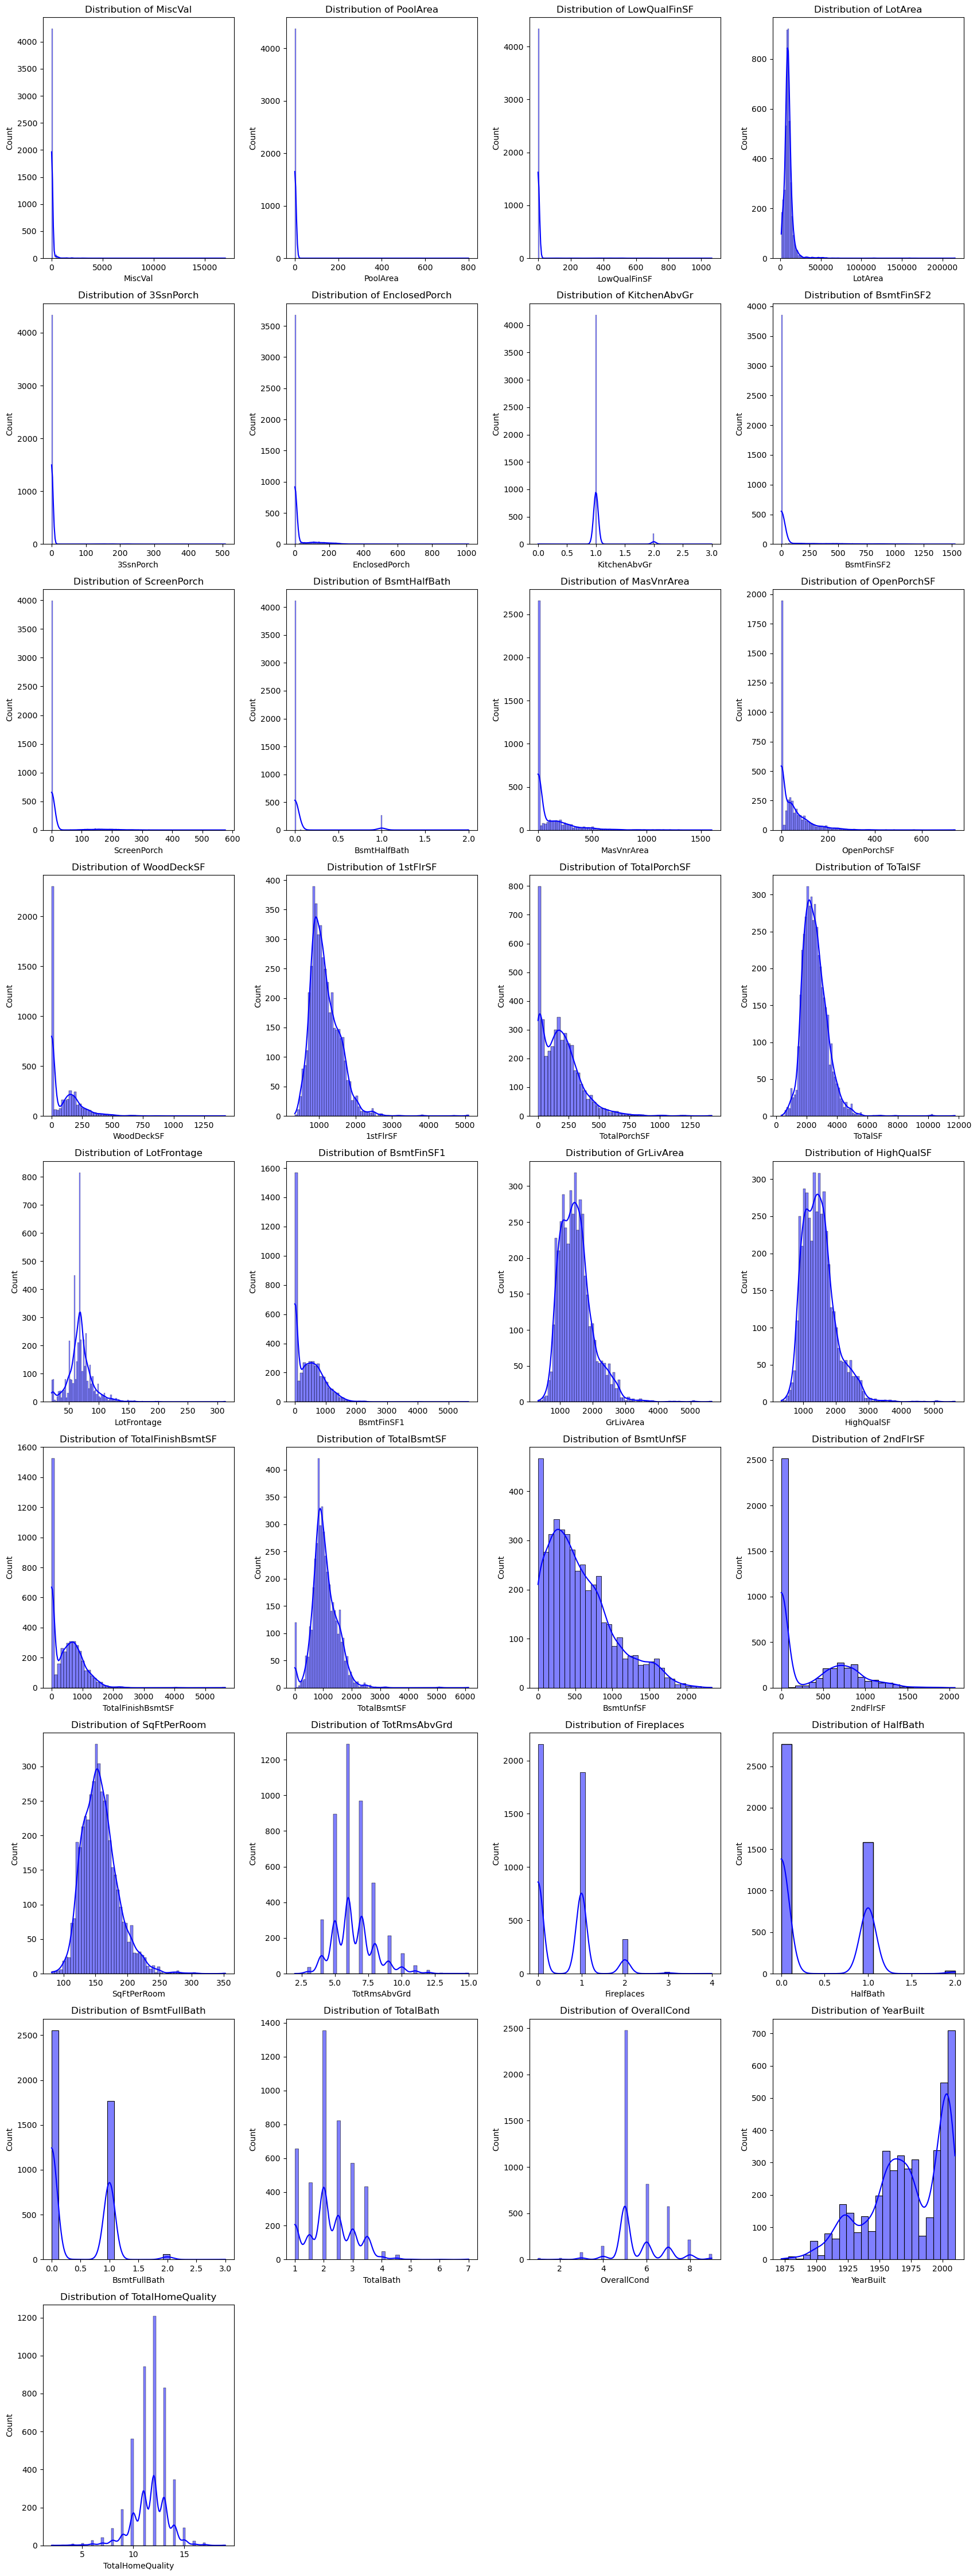

In [94]:
df_num1 = data[x]

ncols = 4
nrows = int(np.ceil(df_num1.shape[1] / ncols))

plt.figure(figsize=(17, 5 * nrows))

for i, col in enumerate(df_num1.columns):
    ax = plt.subplot(nrows, ncols, i + 1)
    sns.histplot(data[col], kde=True, color='blue')
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [95]:
for f in x:
    data[f] = np.log1p(data[f])
data.describe()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,ToTalSF,TotalBath,TotalPorchSF,SqFtPerRoom,TotalHomeQuality,HighQualSF,TotalFinishBsmtSF
count,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000,4389.000000
mean,1706.339713,4.201014,9.087858,6.089542,1.866330,7.586866,1984.065846,2.101708,4.230793,0.694348,5.615672,6.726483,7.002820,2.812339,0.069352,7.258747,0.295288,0.042935,1.568011,0.260144,2.854181,0.710503,1.983604,0.386570,1977.995742,1.766583,472.802823,2.450061,2.344054,0.775302,0.059551,0.463569,0.026271,0.234614,7.793075,1.137483,4.300749,5.048539,2.527242,7.255842,4.339343
std,808.203314,0.323265,0.508025,1.419506,0.174549,0.015431,20.950010,2.620798,2.976634,1.893638,1.874423,1.188694,0.324175,3.270635,0.626489,0.321615,0.352491,0.168810,0.553630,0.341360,0.828321,0.087728,0.204836,0.395154,25.122538,0.765449,215.640082,2.590738,2.154479,1.784250,0.557121,1.476279,0.399838,1.243389,0.312415,0.256092,2.025482,0.171488,0.149849,0.321809,3.035049
min,1.000000,3.091042,7.170888,1.000000,0.693147,7.535297,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.814131,0.000000,0.000000,5.814131,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.098612,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.814131,0.693147,0.000000,4.411585,1.098612,5.814131,0.000000
25%,1098.000000,4.110874,8.912608,5.000000,1.791759,7.577634,1965.000000,0.000000,0.000000,0.000000,5.393628,6.672033,6.775366,0.000000,0.000000,7.025538,0.000000,0.000000,1.000000,0.000000,2.000000,0.693147,1.791759,0.000000,1961.000000,1.000000,319.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.599401,0.916291,3.912023,4.928288,2.484907,7.021084,0.000000
50%,1828.000000,4.251699,9.151757,6.000000,1.791759,7.587817,1993.000000,0.000000,5.899897,0.000000,6.137727,6.896694,6.987490,0.000000,0.000000,7.273093,0.000000,0.000000,2.000000,0.000000,3.000000,0.693147,1.945910,0.693147,1978.132443,2.000000,480.000000,0.000000,3.367296,0.000000,0.000000,0.000000,0.000000,0.000000,7.799343,1.098612,5.117994,5.044858,2.564949,7.268920,6.124683
75%,2376.000000,4.369448,9.354787,7.000000,1.945910,7.601902,2004.000000,5.093750,6.606650,0.000000,6.687109,7.172425,7.233455,6.545350,0.000000,7.458763,0.693147,0.000000,2.000000,0.693147,3.000000,0.693147,2.079442,0.693147,2001.000000,2.000000,576.000000,5.129899,4.262680,0.000000,0.000000,0.000000,0.000000,0.000000,8.002694,1.252763,5.590987,5.155217,2.639057,7.458186,6.698268
max,2930.000000,5.749393,12.279537,10.000000,2.302585,7.606387,2010.000000,7.378384,8.638525,7.331060,7.756623,8.717846,8.536211,7.633370,6.970730,8.638171,1.386294,1.098612,4.000000,1.098612,8.000000,1.386294,2.772589,1.609438,2207.000000,5.000000,1488.000000,7.261927,6.610696,6.920672,6.232448,6.357842,6.685861,9.741027,9.371864,2.079442,7.261927,5.868237,2.995732,8.638171,8.638525


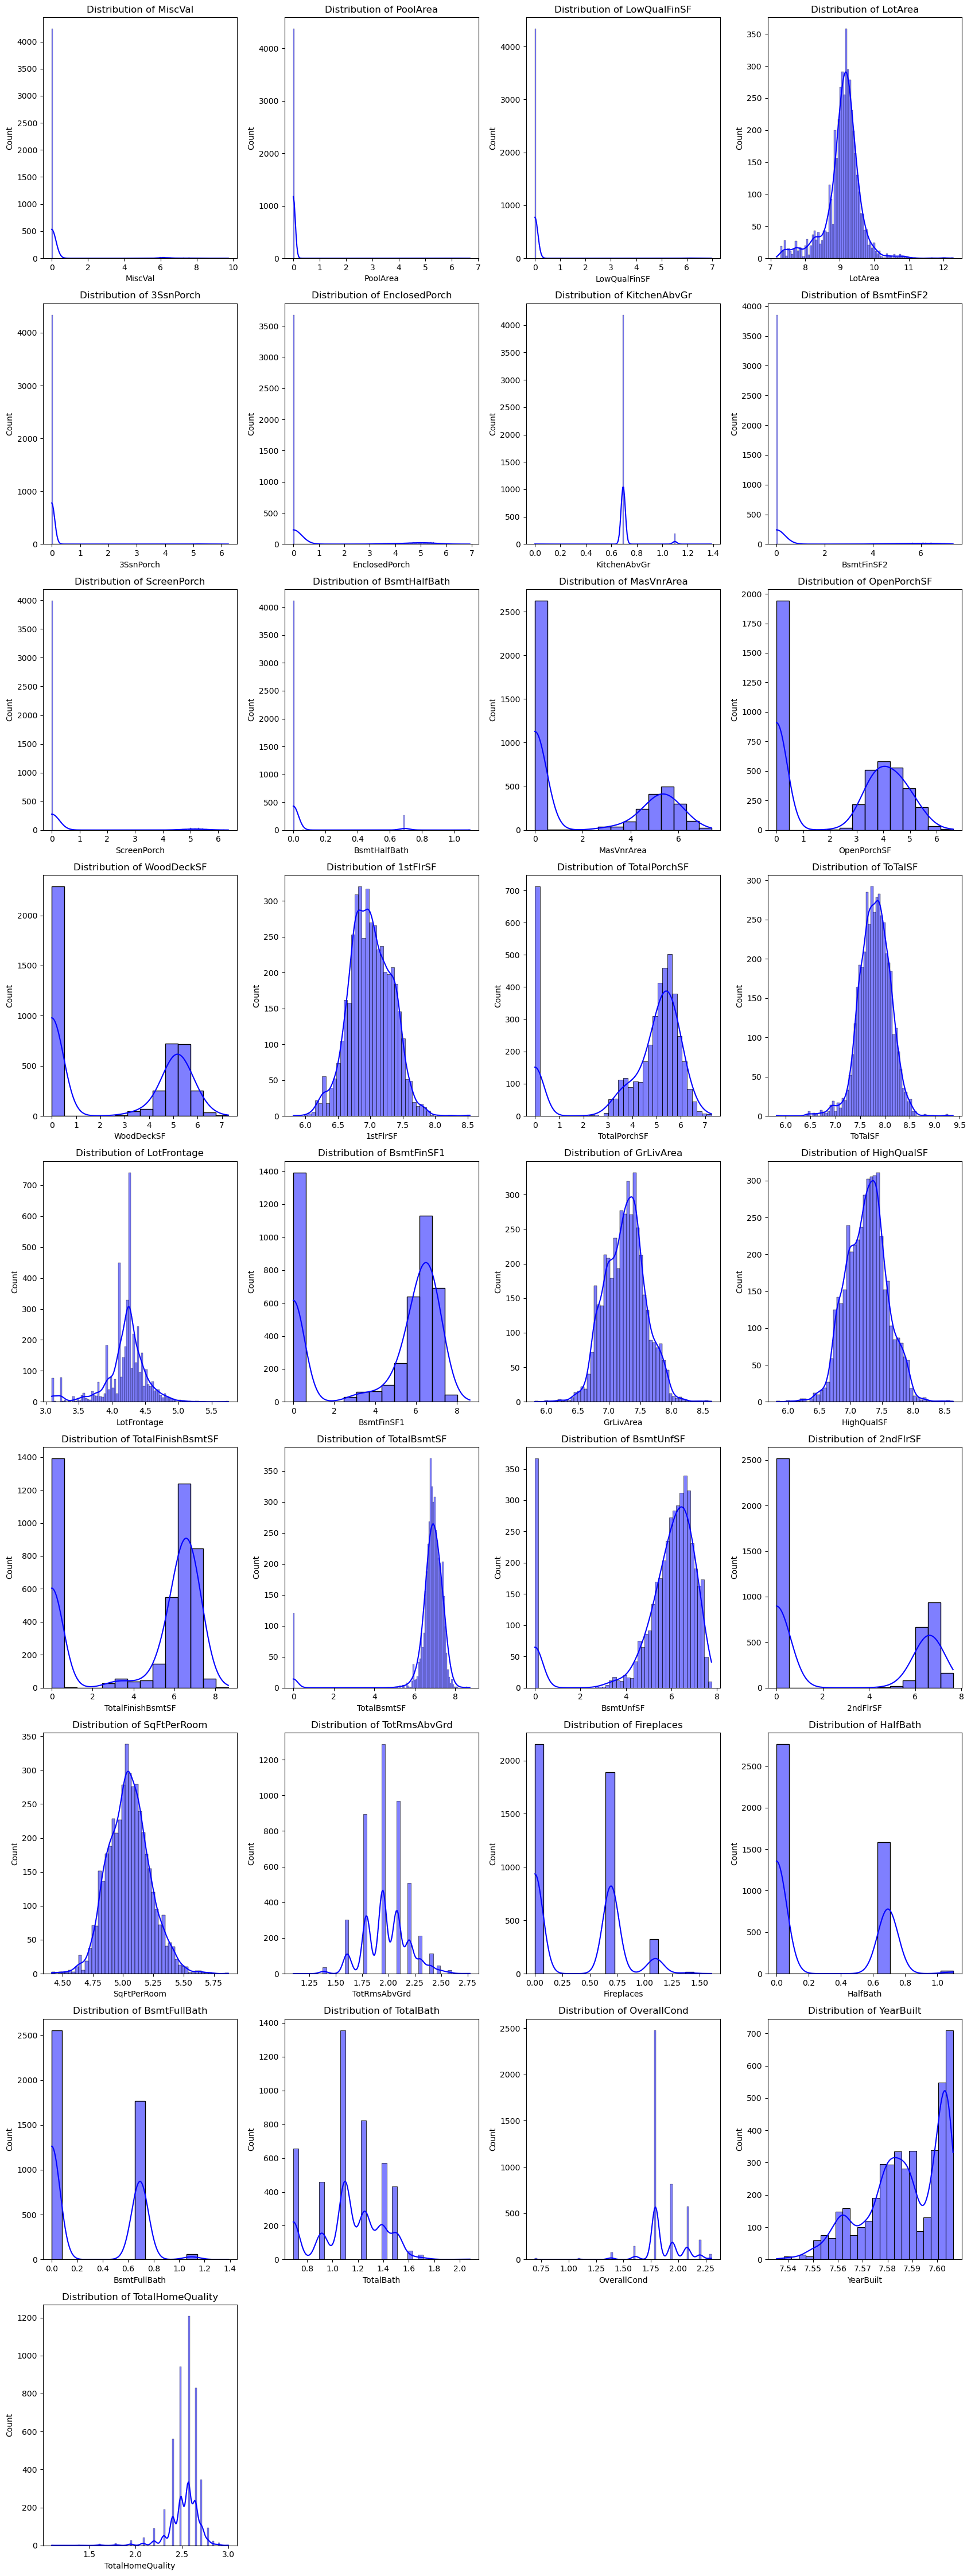

In [96]:
df_num1 = data[x]

ncols = 4
nrows = int(np.ceil(df_num1.shape[1] / ncols))

plt.figure(figsize=(17, 5 * nrows))

for i, col in enumerate(df_num1.columns):
    ax = plt.subplot(nrows, ncols, i + 1)
    sns.histplot(data[col], kde=True, color='blue')
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

<h1 style="text-align: center; color: blue;">
    Encoding category variables
</h1>

In [97]:
def test_mean_target_encoding(train, test, target, categorical, alpha=5):
    # Calculate global mean on the train data
    global_mean = train[target].mean()
    
    # Group by the categorical feature and calculate its properties
    train_groups = train.groupby(categorical)
    category_sum = train_groups[target].sum()
    category_size = train_groups.size()
    
    # Calculate smoothed mean target statistics
    train_statistics = (category_sum + global_mean * alpha) / (category_size + alpha)
    
    # Apply statistics to the test data and fill new categories
    test_feature = test[categorical].map(train_statistics).fillna(global_mean)
    return test_feature.values

In [98]:
from sklearn.model_selection import KFold
def train_mean_target_encoding(train, target, categorical, alpha=5):
    # Create 5-fold cross-validation
    kf = KFold(n_splits=5, random_state=123, shuffle=True)
    train_feature = pd.Series(index=train.index)
    
    # For each folds split
    for train_index, test_index in kf.split(train):
        cv_train, cv_test = train.iloc[train_index], train.iloc[test_index]
      
        # Calculate out-of-fold statistics and apply to cv_test
        cv_test_feature = test_mean_target_encoding(cv_train, cv_test, target, categorical, alpha)
        
        # Save new feature for this particular fold
        train_feature.iloc[test_index] = cv_test_feature       
    return train_feature.values

In [99]:
def mean_target_encoding(train, test, target, categorical, alpha=5):
  
    # Get the train feature
    train_feature = train_mean_target_encoding(train, target, categorical, alpha)
  
    # Get the test feature
    test_feature = test_mean_target_encoding(train, test, target, categorical, alpha)
    
    # Return new features to add to the model
    return train_feature, test_feature

In [100]:
cate = data.select_dtypes('category').columns
data[cate].head()

,MSSubClass,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,MoSold,YrSold,SaleType,SaleCondition,HasPool,HasFỉreplace,HasGarage,HasHouseLevel2,HasBmt
0,20,rl,pave,none,ir1,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,hip,compshg,brkface,plywood,stone,ta,ta,cblock,ta,gd,gd,blq,unf,gasa,fa,y,sbrkr,ta,typ,gd,attchd,fin,ta,ta,p,none,none,none,5,2010,wd,normal,0,1,1,0,1
1,20,rh,pave,none,reg,lvl,allpub,inside,gtl,names,feedr,norm,1fam,1story,gable,compshg,vinylsd,vinylsd,NaN,ta,ta,cblock,ta,ta,no,rec,lwq,gasa,ta,y,sbrkr,ta,typ,none,attchd,unf,ta,ta,y,none,mnprv,none,6,2010,wd,normal,0,0,1,0,1
2,20,rl,pave,none,ir1,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,hip,compshg,wd sdng,wd sdng,brkface,ta,ta,cblock,ta,ta,no,alq,unf,gasa,ta,y,sbrkr,gd,typ,none,attchd,unf,ta,ta,y,none,none,gar2,6,2010,wd,normal,0,0,1,0,1
3,20,rl,pave,none,reg,lvl,allpub,corner,gtl,names,norm,norm,1fam,1story,hip,compshg,brkface,brkface,NaN,gd,ta,cblock,ta,ta,no,alq,unf,gasa,ex,y,sbrkr,ex,typ,ta,attchd,fin,ta,ta,y,none,none,none,4,2010,wd,normal,0,1,1,0,1
4,60,rl,pave,none,ir1,lvl,allpub,inside,gtl,gilbert,norm,norm,1fam,2story,gable,compshg,vinylsd,vinylsd,NaN,ta,ta,pconc,gd,ta,no,glq,unf,gasa,gd,y,sbrkr,ta,typ,ta,attchd,fin,ta,ta,y,none,mnprv,none,3,2010,wd,normal,0,1,1,1,1


In [101]:
X_train = data[:max(train['Id'])]
y_train = train['SalePrice']
df_train = pd.concat([X_train,y_train],axis=1)
df_test = data[max(train['Id']):]

In [102]:
df_train.shape, df_test.shape

((2930, 93), (1459, 92))

In [103]:
for c in data[cate].columns:
    df_train[c] = df_train[c].astype('str')
    df_test[c] = df_test[c].astype('str')
    train_feature, test_feature = mean_target_encoding(df_train, df_test, 'SalePrice', c, alpha=5)
    df_train[c] = train_feature
    df_test[c] = test_feature
df_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,ToTalSF,TotalBath,TotalPorchSF,SqFtPerRoom,TotalHomeQuality,HighQualSF,TotalFinishBsmtSF,HasPool,HasFỉreplace,HasGarage,HasHouseLevel2,HasBmt,SalePrice
0,1,12.053279,12.086144,4.955827,10.366309,12.020160,12.032251,12.187782,12.011431,12.018321,12.026459,12.012976,11.860776,12.036892,12.018396,12.035646,11.996695,6,1.791759,7.581210,1960,12.218759,12.013677,12.013857,11.965834,12.361805,4.727388,11.830194,12.040513,11.869209,11.795345,12.234945,12.395295,11.872323,6.461468,12.020882,0.000000,6.091310,6.985642,12.023288,11.694570,12.056366,12.053253,7.412764,0.000000,0.0,7.412764,0.693147,0.0,1,0.000000,3,0.693147,11.807320,2.079442,12.032986,1.098612,12.265607,12.103704,1960.0,12.318383,2.0,528.0,12.035492,12.034801,11.782760,5.351858,4.143135,0.0,0.0,0.000000,0.0,12.016393,12.051992,12.022646,0.000000,11.971583,11.971811,11.992568,12.001001,7.914618,1.098612,5.609472,5.220356,2.484907,7.412764,6.461468,12.016393,12.217855,12.043235,11.979872,12.031897,12.278398
1,2,12.056869,11.905423,4.394449,9.360741,12.029154,12.039983,11.929646,12.018645,12.027649,12.009018,12.022800,11.869201,11.836529,12.026063,12.047977,12.005557,5,1.945910,7.581720,1961,11.984664,12.025075,12.216563,12.212489,12.027112,0.000000,11.836221,12.047822,11.870151,11.795421,12.028835,11.937776,11.838519,6.150603,12.003807,4.976734,5.602119,6.783325,12.033737,11.801291,12.065826,12.065025,6.799056,0.000000,0.0,6.799056,0.000000,0.0,1,0.000000,2,0.693147,11.815815,1.791759,12.042453,0.000000,11.813518,12.107842,1961.0,11.784138,1.0,730.0,12.044766,12.041124,12.071710,4.948760,0.000000,0.0,0.0,4.795791,0.0,12.025534,11.863377,12.031464,0.000000,12.029976,11.971222,11.998699,12.010184,7.483807,0.693147,5.564520,4.859812,2.484907,6.799056,6.418365,12.025534,11.813518,12.055482,11.988920,12.040817,11.561725
2,3,12.056031,12.085561,4.406719,9.565775,12.021623,12.032823,12.187479,12.012794,12.019866,12.003913,12.014718,11.863464,12.039494,12.019763,12.037896,12.005414,6,1.945910,7.580189,1958,12.213997,12.016073,11.829125,11.833627,12.192993,4.691348,11.830450,12.042288,11.856878,11.791826,12.027870,11.925788,11.966917,6.828712,12.022097,0.000000,6.008813,7.192934,12.025090,11.795140,12.059342,12.053310,7.192934,0.000000,0.0,7.192934,0.000000,0.0,1,0.693147,3,0.693147,12.211527,1.945910,12.032962,0.000000,11.806396,12.107207,1958.0,11.776582,1.0,312.0,12.035914,12.035741,12.064792,5.976351,3.610918,0.0,0.0,0.000000,0.0,12.017702,12.054428,11.935582,9.433564,12.027130,11.975457,11.993451,12.004523,7.885705,0.916291,6.063785,5.001707,2.564949,7.192934,6.828712,12.017702,11.806396,12.049438,11.986344,12.031822,12.055256
3,4,12.056869,12.087640,4.543295,9.320181,12.029154,12.039983,11.929646,12.018645,12.027649,12.015130,12.022800,11.869201,12.042563,12.026063,12.047977,12.005557,7,1.791759,7.585281,1968,12.210576,12.025075,12.116594,12.120323,12.027112,0.000000,12.303758,12.047822,11.870151,11.795421,12.028835,11.937776,11.963459,6.971669,12.031488,0.000000,6.952729,7.654917,12.033737,12.211957,12.065826,12.065025,7.654917,0.000000,0.0,7.654917,0.693147,0.0,2,0.693147,3,0.693147,12.633193,2.197225,12.042453,1.098612,12.173097,12.107842,196

In [104]:
df_test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,ToTalSF,TotalBath,TotalPorchSF,SqFtPerRoom,TotalHomeQuality,HighQualSF,TotalFinishBsmtSF,HasPool,HasFỉreplace,HasGarage,HasHouseLevel2,HasBmt
2930,1461,12.058718,11.821934,4.394449,9.360741,12.023274,12.035067,11.920338,12.014539,12.021527,12.002962,12.016569,11.865478,11.815867,12.021054,12.040096,12.002775,5,1.945910,7.581720,1961,11.977413,12.017654,12.222291,12.220010,12.020975,0.000000,11.832032,12.043558,11.865013,11.792223,12.027327,11.928708,11.830120,6.150603,11.971892,4.976734,5.602119,6.783325,12.026884,11.795534,12.061291,12.058021,6.799056,0.000000,0.0,6.799056,0.0,0.0,1,0.000000,2,0.693147,11.807513,1.791759,12.036759,0.000000,11.808021,12.106512,1961.0,11.778119,1.0,730.0,12.03807,12.037475,12.068588,4.948760,0.000000,0.0,0.0,4.795791,0.0,12.019189,11.847896,12.025576,0.000000,12.026080,11.975983,11.994387,12.00528,7.483807,0.693147,5.564520,4.859812,2.484907,6.799056,6.418365,12.019189,11.808021,12.049977,11.985034,12.034953
2931,1462,12.058718,12.086285,4.406719,9.565775,12.023274,12.035067,12.187988,12.014539,12.021527,12.014149,12.016569,11.865478,12.039795,12.021054,12.040096,12.002775,6,1.945910,7.580189,1958,12.213307,12.017654,11.835358,11.837122,12.188031,4.691348,11.832032,12.043558,11.865013,11.792223,12.027327,11.928708,11.964832,6.828712,12.025029,0.000000,6.008813,7.192934,12.026884,11.795534,12.061291,12.058021,7.192934,0.000000,0.0,7.192934,0.0,0.0,1,0.693147,3,0.693147,12.214744,1.945910,12.036759,0.000000,11.808021,12.106512,1958.0,11.778119,1.0,312.0,12.03807,12.037475,12.068588,5.976351,3.610918,0.0,0.0,0.000000,0.0,12.019189,12.056018,11.948223,9.433564,12.026080,11.975983,11.994387,12.00528,7.885705,0.916291,6.063785,5.001707,2.564949,7.192934,6.828712,12.019189,11.808021,12.049977,11.985034,12.034953
2932,1463,12.336090,12.086285,4.317488,9.534668,12.023274,12.035067,12.187988,12.014539,12.021527,12.002962,12.016569,12.141866,12.039795,12.021054,12.040096,12.164527,5,1.791759,7.599902,1998,11.977413,12.017654,12.222291,12.220010,12.020975,0.000000,11.832032,12.043558,12.266696,12.176155,12.027327,11.928708,12.241246,6.674561,12.025029,0.000000,4.927254,6.834109,12.026884,11.910833,12.061291,12.058021,6.834109,6.553933,0.0,7.396335,0.0,0.0,2,0.693147,3,0.693147,11.807513,1.945910,12.036759,0.693147,12.181121,12.106512,1997.0,12.318059,2.0,482.0,12.03807,12.037475,12.068588,5.361292,3.555348,0.0,0.0,0.000000,0.0,12.019189,11.847896,12.025576,0.000000,11.990947,11.975983,11.994387,12.00528,7.846981,1.252763,5.509388,5.099256,2.397895,7.396335,6.674561,12.019189,12.221825,12.049977,12.069097,12.034953
2933,1464,12.336090,12.086285,4.369448,9.208238,12.023274,12.035067,12.187988,12.014539,12.021527,12.002962,12.016569,12.141866,12.039795,12.021054,12.040096,12.164527,6,1.945910,7.600402,1998,11.977413,12.017654,12.222291,12.220010,12.188031,3.044522,11.832032,12.043558,12.266696,11.792223,12.027327,11.928708,12.241246,6.401917,12.025029,0.000000,5.783825,6.831954,12.026884,12.212534,12.061291,12.058021,6.831954,6.520621,0.0,7.380879,0.0,0.0,2,0.693147,3,0.693147,12.214744,2.079442,12.036759,0.693147,12.272074,12.106512,1998.0,12.318059,2.0,470.0,12.03807,12.037475,

In [105]:
# df_train = df_train.drop(['YearRemodAdd','GarageYrBlt'],axis=1)
df_train['YearUse'] = df_train['YrSold'] - df_train['YearBuilt']
# df_test = df_test.drop(['YearRemodAdd','GarageYrBlt'],axis=1)
df_test['YearUse'] = df_test['YrSold'] - df_test['YearBuilt']

In [106]:
df_train[df_train['YearUse']<0]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,ToTalSF,TotalBath,TotalPorchSF,SqFtPerRoom,TotalHomeQuality,HighQualSF,TotalFinishBsmtSF,HasPool,HasFỉreplace,HasGarage,HasHouseLevel2,HasBmt,SalePrice,YearUse


<h1 style="text-align: center; color: blue;">
    MODELING SELECTION
</h1>

In [107]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split, GridSearchCV, KFold , RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [108]:
X_tr = df_train.drop(['SalePrice', 'Id'], axis=1)
y = df_train['SalePrice']

def mse(y, y_pred):
    return mean_squared_error(y, y_pred)

def cv_mse(model):
    mse_scores = -cross_val_score(
        model,
        X_tr,
        y,
        scoring='neg_mean_squared_error',
        cv=kf,
        n_jobs=-1
    )
    return mse_scores

In [109]:
# 10-Fold Cross Validation
kf = KFold(
    n_splits=10,
    random_state=42,
    shuffle=True
)

cv_scores = []
cv_std = []

baseline_models = [
    'Linear Regression',
    'Ridge Regression',
    'Lasso Regression',
    'Elastic Net',
    'Decision Tree Regression',
    'Random Forest Regression',
    'CatBoost Regression'
]


# 1. Linear Regression
linear_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

score_linear = cv_mse(linear_model)

cv_scores.append(score_linear.mean())
cv_std.append(score_linear.std())


# 2. Ridge Regression
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

score_ridge = cv_mse(ridge_model)

cv_scores.append(score_ridge.mean())
cv_std.append(score_ridge.std())


# 3. Lasso Regression
lasso_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(alpha = 0.01))
])

score_lasso = cv_mse(lasso_model)

cv_scores.append(score_lasso.mean())
cv_std.append(score_lasso.std())


# 4. Elastic Net
elastic_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(alpha = 0.01))
])

score_elastic = cv_mse(elastic_model)

cv_scores.append(score_elastic.mean())
cv_std.append(score_elastic.std())


# 5. Decision Tree Regression
decision_tree_model = DecisionTreeRegressor()

score_decision_tree = cv_mse(decision_tree_model)

cv_scores.append(score_decision_tree.mean())
cv_std.append(score_decision_tree.std())


# 6. Random Forest Regression
random_forest_model = RandomForestRegressor()

score_random_forest = cv_mse(random_forest_model)

cv_scores.append(score_random_forest.mean())
cv_std.append(score_random_forest.std())


# 7. CatBoost Regression
catboost_model = CatBoostRegressor(
    verbose=0
)

score_catboost = cv_mse(catboost_model)

cv_scores.append(score_catboost.mean())
cv_std.append(score_catboost.std())


# Tổng hợp kết quả
final_cv_score = pd.DataFrame({
    'Regressors': baseline_models,
    'MSE_mean': cv_scores,
    'MSE_std': cv_std
})

# Sắp xếp MSE từ thấp đến cao
final_cv_score = final_cv_score.sort_values(
    by='MSE_mean',
    ascending=True
).reset_index(drop=True)

final_cv_score

,Regressors,MSE_mean,MSE_std
0,CatBoost Regression,0.013130,0.003835
1,Ridge Regression,0.015973,0.004591
2,Linear Regression,0.015999,0.004600
3,Elastic Net,0.016007,0.004325
4,Lasso Regression,0.016707,0.004329
5,Random Forest Regression,0.017565,0.003676
6,Decision Tree Regression,0.036978,0.008229


In [110]:
import seaborn as sns

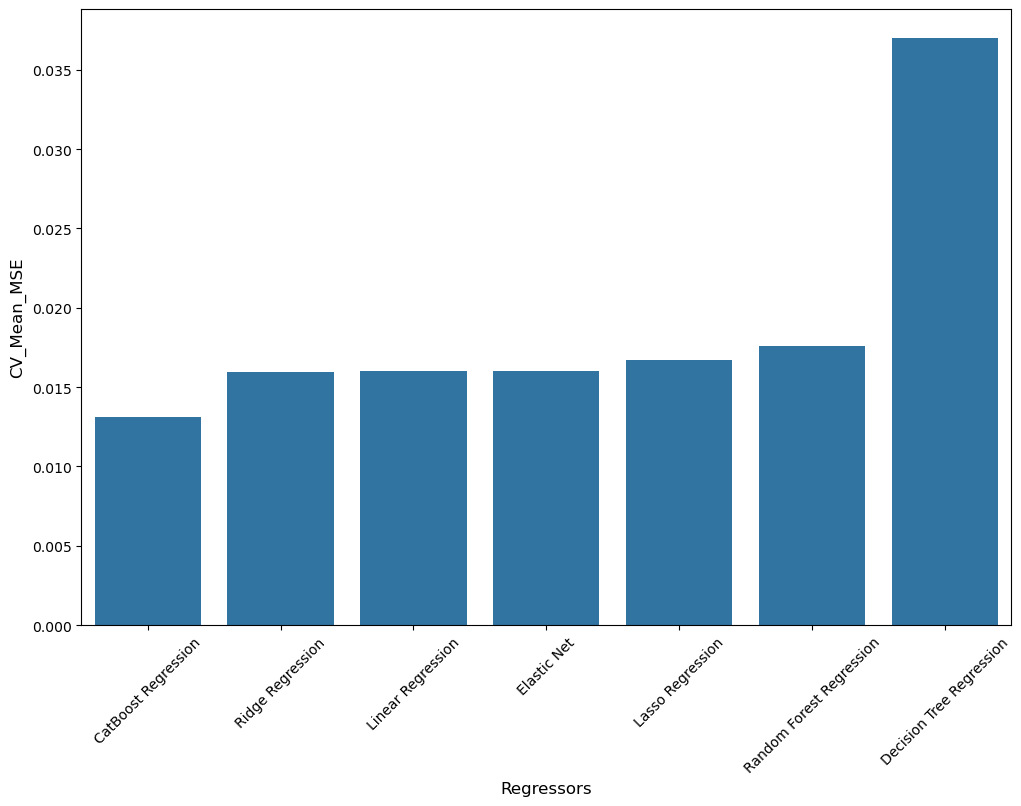

In [111]:
plt.figure(figsize = (12,8))
# sns.barplot(final_cv_score['Regressors'],final_cv_score['MSE_mean'])
sns.barplot(x='Regressors', y='MSE_mean', data=final_cv_score)
plt.xlabel('Regressors', fontsize = 12)
plt.ylabel('CV_Mean_MSE', fontsize = 12)
plt.xticks(rotation=45)
plt.show()

In [112]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_tr,
    y,
    test_size=0.1,
    random_state=42
)

In [113]:
ridge_model = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](92,)","['MSSubClass','MSZoning','LotFrontage',...,'HasHouseLevel2','HasBmt', 'YearUse']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,92
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [114]:
ridge_pred = ridge_model.predict(X_val)

ridge_score = mean_squared_error(
    y_val,
    ridge_pred
)

print('Ridge MSE:', ridge_score)

Ridge MSE: 0.015593476288628512


In [115]:
# Hệ số đặc trưng
ridge_coef = ridge_model.named_steps['ridge'].coef_

feat_imp = pd.DataFrame({
    'Feature': X_tr.columns,
    'Coefficient': ridge_coef,
    'Importance': np.abs(ridge_coef)
}).sort_values(
    by='Importance',
    ascending=False
)

display(feat_imp.head(20))

,Feature,Coefficient,Importance
89,HasHouseLevel2,-0.107768,0.107768
43,2ndFlrSF,0.097154,0.097154
82,SqFtPerRoom,0.059639,0.059639
53,TotRmsAbvGrd,0.058863,0.058863
16,OverallQual,0.057657,0.057657
79,ToTalSF,0.049591,0.049591
11,Neighborhood,0.047651,0.047651
78,SaleCondition,0.035156,0.035156
22,Exterior1st,0.034552,0.034552
3,LotArea,0.032241,0.032241


<h1 style="text-align: center; color: blue;">
    TUNNING
</h1>

In [116]:
# Tuning alpha
grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 150, 200, 500, 1000]
}

grid_search = GridSearchCV(
    estimator=ridge_model,
    param_grid=grid,
    scoring='neg_mean_squared_error',
    cv=10,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print('Best params:', grid_search.best_params_)
print('Best CV MSE:', -grid_search.best_score_)

Best params: {'ridge__alpha': 150}
Best CV MSE: 0.01591376593783125


In [117]:
# Mô hình tốt nhất
ridge_model_f = grid_search.best_estimator_

# Đánh giá lại validation
ridgef_pred = ridge_model_f.predict(X_val)

ridgef_score = mean_squared_error(
    y_val,
    ridgef_pred
)

print('Tuned Ridge MSE:', ridgef_score)

Tuned Ridge MSE: 0.015091874683162173


In [118]:
# Huấn luyện lại trên toàn bộ tập train
ridge_model_f.fit(X_tr, y)

# Dự đoán tập test
X_test = df_test.drop(columns=['Id'])

test_pred_log = ridge_model_f.predict(X_test)
test_pred = np.expm1(test_pred_log)

# Tạo submission
submission = pd.DataFrame({
    'Id': df_test['Id'],
    'SalePrice': test_pred
})

submission.to_csv(
    'ridge_submission.csv',
    index=False
)

submission.head()

,Id,SalePrice
2930,1461,114416.314360
2931,1462,147023.944364
2932,1463,180586.365062
2933,1464,196035.055568
2934,1465,214957.878808


In [119]:
# Dự đoán trên tập train
train_pred = ridge_model_f.predict(X_train)

# Dự đoán trên tập validation
val_pred = ridge_model_f.predict(X_val)

# Tính MSE
train_mse = mean_squared_error(y_train, train_pred)
val_mse = mean_squared_error(y_val, val_pred)

print('Train MSE:', train_mse)
print('Validation MSE:', val_mse)
print('Khoảng chênh lệch:', val_mse - train_mse)

Train MSE: 0.01437754012948061
Validation MSE: 0.014049468724853187
Khoảng chênh lệch: -0.0003280714046274228
